# Выпускной проект. A/B-тест

<a id=content></a>
### Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации</b>](#1)
    <br>[1.1. Загрузка данных](#1.1)
    <br>[1.2. Общая информация о массивах данных](#1.2)
2. [<b>Предварительная обработка данных</b>](#2)
    <br>[2.1. Изучение типов данных и их преобразование в случае необходимости](#2.1)
    <br>[2.2. Проверка на пропуски](#2.2)
    <br>[2.3. Проверка на дубликаты](#2.3)
3. [<b>Подготовка данных в соответствии с техническим заданием</b>](#3)
    <br>[3.1. Изучение данных контрольной и тестовой групп на пересечение значений](#3.1)
    <br>[3.2. Изучение хронологических рамок проведения теста](#3.2)
    <br>[3.3. Формирование аудитории теста](#3.3)
    <br>[3.4. Вычисление количества участников теста](#3.4)
    <br>[3.5. Установление соответствия результатов теста ожидаемому эффекту](#3.5)
4. [<b>Исследовательский анализ данных</b>](#4)
    <br>[4.1. Сколько всего событий в логе и как часто они происходят?](#4.1)
    <br>[4.2. Сколько всего пользователей и сколько в среднем событий приходится на пользователя?](#4.2)
    <br>[4.3. Распределение событий по пользователям: обобщённые и групповые данные](#4.3)
    <br>[4.4. Пользовательские девайсы, их представленность и ретроспектива использования](#4.4)
    <br>[4.5. Оценка пользовательской активности](#4.5)
5. [<b>Анализ A/B-теста и оценка его результатов</b>](#5)
    <br>[5.1. График кумулятивной выручки по группам](#5.1)
    <br>[5.2. График кумулятивного среднего чека по группам](#5.2)
    <br>[5.3. График относительного изменения кумулятивного среднего чека группы B к группе A](#5.3)
    <br>[5.4. График кумулятивного среднего количества заказов на посетителя по группам](#5.4)
    <br>[5.5. График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A](#5.5)
    <br>[5.6. Диаграмма рассеяния количества заказов по пользователям](#5.6)
    <br>[5.7. Расчёт 95-го и 99-го перцентиля количества заказов на пользователя](#5.7)
    <br>[5.8. Диаграмма рассеяния стоимостей заказов](#5.8)
    <br>[5.9. Расчёт 95-го и 99-го перцентиля стоимости заказов](#5.9)
    <br>[5.10. Расчёт статистической значимости различий в среднем количестве заказов на посетителя между группами](#5.10)
    <br>[5.11. Расчёт статистической значимости различий в доле пользователей контрольной и экспериментальной группы на каждом шаге воронки событий](#5.11)
    <br>[5.12. Принятое решение по результатам A/B-теста и его аргументация](#5.12)
6. [<b>Вывод</b>](#6)

<br>[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6)

## Описание проекта

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении есть датасет с действиями пользователей, техническое задание и несколько вспомогательных датафреймов.
Оцените корректность проведения теста и проанализируйте его результаты.
Чтобы оценить корректность проведения теста:

* удостоверьтесь, что нет пересечений с конкурирующим тестом и нет пользователей, участвующих в двух группах теста одновременно;
* проверьте равномерность распределения пользователей по тестовым группам и правильность их формирования.

## Описание данных

В работу поступили 4 датафрейма, изучим их структуру и содержание подробнее.

**Календарь маркетинговых событий на 2020 год** и его описание хранится в датафрейме `ab_project_marketing_events.csv` общим размером 14 строк на 4 столбца. 

*Таблица 1. Общая информация по датафрейму `ab_project_marketing_events.csv`*

|№ п/п|Наименование признака|Описание признака|Ед.|Размах значений признака|
|-----|---------------------|:----------------|:--|:-----------------------|
|1.   |`name`|наименование маркетингового события|14 уникальных наименований макертинговых событий|маркетинговые события <br> 'Christmas&New Year Promo' - акция к Рождеству и Новому году <br>'St. Valentine's Day Giveaway' - акция ко Дню святого Валентина <br>'St. Patric's Day Promo' - акция ко Дню святого Патрика <br>'Easter Promo' - акция к празднованию Пасхи <br>'4th of July Promo' - акция к празднованию Дня независимости США <br>'Black Friday Ads Campaign' - Чёрная пятница <br>'Chinese New Year Promo' - акция к китайскому Новому году <br>'Labor day (May 1st) Ads Campaign' - акция к празднованию Дня весны и труда <br>'International Women's Day Promo' - акция к празднованию 8 Марта <br>'Victory Day CIS (May 9th) Event' - акция к празднованию Дня Победы <br>'CIS New Year Gift Lottery' - Новогодняя лотерея-розыгрыш <br>'Dragon Boat Festival Giveaway' - акция к празднику Дуаньду (драконьих лодок) <br>'Single's Day Gift Promo' - акция ко Дню холостяков <br>'Chinese Moon Festival' - акция к празднику Дня середины осени и лунных пряников|
|2.   |`regions`|регионы, в которых будет проводиться рекламная кампания|6 уникальных наименований регионов|'EU, N.America' - Европа, Северная Америка <br>'EU, CIS, APAC, N.America' - Европа, СНГ, Азиатско-Тихоокеанский регион, Севеорная Америка <br>'N.America' - Северная Америка <br>'APAC' - Азиатско-Тихоокеанский регион <br>'EU, CIS, APAC' - Европа, СНГ, Азиатско-Тихоокеанский регион <br>'CIS' - СНГ|
|3.   |`start_dt`|дата начала кампании|14 уникальных дат|от 2020-01-25 до 2020-12-30|
|4.   |`finish_dt`|дата завершения кампании|14 уникальных дат|от 2020-02-07 до 2021-01-07|


**Все пользователи, зарегистрировавшиеся в интернет-магазине в период с 7 декабря 2020 года по 21 декабря 2020 года** и его описание хранится в датафрейме `final_ab_new_users.csv` общим размером 61733 строк на 4 столбца. 

*Таблица 2. Общая информация по датафрейму `final_ab_new_users.csv`*

|№ п/п|Наименование признака|Описание признака|Ед.|Размах значений признака|
|-----|---------------------|:----------------|:--|:-----------------------|
|1.   |`user_id`|идентификатор пользователя|61733 уникальных идентификатора пользователей|от 0001710F4DDB1D1B до FFFFE36C0F6E92DF|
|2.   |`first_date`|дата регистрации пользователя|17 уникальных дат|'2020-12-07', '2020-12-14', '2020-12-21', '2020-12-08', '2020-12-15', '2020-12-22', '2020-12-09', '2020-12-16', '2020-12-23', '2020-12-10', '2020-12-17', '2020-12-11', '2020-12-18', '2020-12-12', '2020-12-19', '2020-12-13', '2020-12-20'|
|3.   |`region`|регион пользователя|4 уникальных региона|'EU', 'N.America', 'APAC', 'CIS'|
|4.   |`device`|устройство, с которого происходила регистрация|4 уникальных типа устройства|'PC', 'Android', 'iPhone', 'Mac'|


**Все события новых пользователей в период с 7 декабря 2020 по 4 января 2021 года** и его описание хранится в датафрейме `final_ab_events.csv` общим размером 440317 строк на 4 столбца. 

*Таблица 3. Общая информация по датафрейму `final_ab_events.csv`*

|№ п/п|Наименование признака|Описание признака|Ед.|Размах значений признака|
|-----|---------------------|:----------------|:--|:-----------------------|
|1.   |`user_id`|идентификатор пользователя|58703 уникальных идентификаторов пользователей|от 0001710F4DDB1D1B до FFFFE36C0F6E92DF|
|2.   |`event_dt`|дата и время события|267268 уникальных дат|от 2020-12-07 00:00:33 до 2020-12-30 23:36:33|
|3.   |`event_name`|тип события|4 уникальных типа события|типы событий: <br>'purchase' - покупка <br>'product_cart' - просмотр корзины <br>'product_page' - просмотр карточки товара <br>'login' - пользователь вошёл в систему |
|4.   |`details`|дополнительные данные о событии|4 уникальных значения|для покупок `purchase` это стоимость покупки в долларах: 4.99, 9.99, 99.99, 499.99, для логина в системе `login`, просмотра карточки товара `product_page` и для просмотра корзины `product_cart` это значение NaN|

**Таблица участников теста** и её описание хранится в датафрейме `final_ab_participants.csv` общим размером 18268 строк на 3 столбца. 

*Таблица 4. Общая информация по датафрейму `final_ab_participants.csv`*

|№ п/п|Наименование признака|Описание признака|Ед.|Размах значений признака|
|-----|---------------------|:----------------|:--|:-----------------------|
|1.   |`user_id`|идентификатор пользователя|16666 уникальных идентификаторов пользователей|от 0002CE61FF2C4011 до FFF58BC33966EB51|
|2.   |`group`  |группа пользователя|2 уникальные группы|от A до B|
|3.   |`ab_test`|название теста|2 уникальных названия теста|'recommender_system_test' -  внедрение улучшенной рекомендательной системы <br>'interface_eu_test' - внедрение нового дизайна интерфейса|

Данные получены посредством последовательного применения методов `len()`, `unique()`, `min()`, `max()` к вышеперечисленным датафреймам.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=1></a>
### Шаг 1. Загрузка данных и получение общей информации

<a id=1.1></a>
#### 1.1. Загрузка данных

In [1]:
# импорт библиотек
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
import plotly.express as px
from plotly import graph_objects as go
import math
from scipy import stats as st

# устанавливаем опцию вывода всех столбцов
pd.set_option('display.max_columns', None)

# устанавливаем опцию вывода максимальной ширины столбцов
pd.set_option('display.max_colwidth', None)

# устанавливаем форматирование отображения чисел типа `float` с двумя знаками после запятой
pd.options.display.float_format ='{:.2f}'.format

# игнорирование системных предупреждений об обновлениях работы функций
import warnings
warnings.simplefilter('ignore')

# настройка вывода визуализации
%matplotlib inline

In [2]:
# загрузка файлов в датафреймы
try:
    marketing_calendar = pd.read_csv('https://code.s3.yandex.net/datasets/ab_project_marketing_events.csv')
    users_regions = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_new_users.csv')
    users_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_events.csv')
    groups = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_participants.csv')

except:
    marketing_calendar  = pd.read_csv('ab_project_marketing_events.csv')
    users_regions = pd.read_csv('final_ab_new_users.csv')
    users_events = pd.read_csv('final_ab_events.csv')
    groups = pd.read_csv('final_ab_participants.csv')

<a id=1.2></a>
#### 1.2. Общая информация о массивах данных

In [3]:
# выводим датафреймы для ознакомления
display(marketing_calendar.head())
display(users_regions.head())
display(users_events.head())
display(groups.head())

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,482F14783456D21B,B,recommender_system_test


In [4]:
# выводим основную информацию о количестве записей, количестве ненулевых значений, типах признаков
display(marketing_calendar.info())
display(users_regions.info())
display(users_events.info())
display(groups.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61733 entries, 0 to 61732
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     61733 non-null  object
 1   first_date  61733 non-null  object
 2   region      61733 non-null  object
 3   device      61733 non-null  object
dtypes: object(4)
memory usage: 1.9+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440317 entries, 0 to 440316
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     440317 non-null  object 
 1   event_dt    440317 non-null  object 
 2   event_name  440317 non-null  object 
 3   details     62740 non-null   float64
dtypes: float64(1), object(3)
memory usage: 13.4+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18268 entries, 0 to 18267
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  18268 non-null  object
 1   group    18268 non-null  object
 2   ab_test  18268 non-null  object
dtypes: object(3)
memory usage: 428.3+ KB


None

In [5]:
# выводим первичный статистический анализ по числовым признакам
display(marketing_calendar.describe())
display(users_regions.describe())
display(users_events.describe())
display(groups.describe())

,name,regions,start_dt,finish_dt
count,14,14,14,14
unique,14,6,14,14
top,Christmas&New Year Promo,APAC,2020-12-25,2021-01-03
freq,1,4,1,1


,user_id,first_date,region,device
count,61733,61733,61733,61733
unique,61733,17,4,4
top,D72A72121175D8BE,2020-12-21,EU,Android
freq,1,6290,46270,27520


,details
count,62740.00
mean,23.88
std,72.18
min,4.99
25%,4.99
50%,4.99
75%,9.99
max,499.99


,user_id,group,ab_test
count,18268,18268,18268
unique,16666,2,2
top,95401934D6D6D4FC,A,interface_eu_test
freq,2,9655,11567


**Вывод:** на этом этапе нами был импортирован ряд библиотек, в том числе `pandas` для работы с массивами данных, `plotly`, `matplotlib` и `seaborn` для визуализации полученных результатов, а также модуль `stats` библиотеки `scipy` для корректной работы со статистическими гипотезами.

Осуществлена загрузка исходных данных методом `read_csv`. В работу поступили 4 датафрейма, содержащие ту или иную информацию для исследования: данные о самих маркетинговых событиях - акциях, лотереях, рекламных кампаниях в период с 25 января 2020 года по 1 июля 2021 года (14 строк на 4 столбца); данные о пользователях, зарегистрировавшихся в интернет-магазине в период с 7 по 21 декабря 2020 года (61733 строк на 4 столбца); данные о событиях новых пользователей в период с 7 декабря 2020 по 4 января 2021 года (440317 строк на 4 столбца и, собственно, таблица с обезличенными данными участников A/B-тестирования (18268 строк на 3 столбца).

На основании результатов последовательного применения методов `min()`, `max()`, `unique()`, `info()` и `describe()` мы получили первичную информацию для статистического анализа. Исходные датафреймы разноразмерны. При первичном исследовании данных выявлено несоответствие типов хранимой информации, а также наличие пропусков. Изучим более подробно массивы данных в следующем исследовательском разделе проекта.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=2></a>
### Шаг 2. Предварительная обработка данных

<a id=2.1></a>
#### 2.1. Изучение типов данных и их преобразование в случае необходимости

В процессе формирования обобщённой информации нами установлено несоответствие типа признака хранимой информации по ряду признаков в нескольких датафреймах:

|Наименование датафрейма|наименование переменной|Название признака|Текущий тип данных|Требуемый тип данных|
|-----------------------|:----------------------|:----------------|:-----------------|:-------------------|
|`ab_project_marketing_events.csv`|`marketing_calendar`|'start_dt'|object|datetime|
|`ab_project_marketing_events.csv`|`marketing_calendar`|'finish_dt'|object|datetime|
|`final_ab_new_users.csv`|`users_regions`|'first_date'|object|datetime|
|`final_ab_events.csv`|`users_events`|'event_dt'|object|datetime|

In [6]:
# выполняем преобразование типов данных
marketing_calendar['start_dt'] = pd.to_datetime(marketing_calendar['start_dt'])
marketing_calendar['finish_dt'] = pd.to_datetime(marketing_calendar['finish_dt'])
users_regions['first_date'] = pd.to_datetime(users_regions['first_date'])
users_events['event_dt'] = pd.to_datetime(users_events['event_dt'])

In [7]:
# проверка результатов преобразования
marketing_calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     object        
 1   regions    14 non-null     object        
 2   start_dt   14 non-null     datetime64[ns]
 3   finish_dt  14 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 580.0+ bytes


In [8]:
# проверка результатов преобразования
users_regions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61733 entries, 0 to 61732
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     61733 non-null  object        
 1   first_date  61733 non-null  datetime64[ns]
 2   region      61733 non-null  object        
 3   device      61733 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.9+ MB


In [9]:
# проверка результатов преобразования
users_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440317 entries, 0 to 440316
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     440317 non-null  object        
 1   event_dt    440317 non-null  datetime64[ns]
 2   event_name  440317 non-null  object        
 3   details     62740 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 13.4+ MB


<a id=2.2></a>
#### 2.2. Проверка на пропуски

In [10]:
# функция для проверки пропусков в данных
def check_isna(*data):
    df_missing = pd.DataFrame(columns=['название признака', 'количество пропусков', '% пропущенных значений'])
    j = 0
    
    for dataset in data:
        for i, col in enumerate(dataset.columns):
            percent_missing = np.mean(dataset[col].isnull())
            value_missing = np.sum(dataset[col].isnull())

            if percent_missing != 0:
                df_missing.loc[j] = [col, value_missing, (percent_missing*100).round(2)]
                j += 1
    
    return df_missing.sort_values(by='количество пропусков', ascending=True)

In [11]:
# проверка на пропуски
check_isna(marketing_calendar, users_regions, users_events, groups)

,название признака,количество пропусков,% пропущенных значений
0,details,377577,85.75


По итогам предварительного знакомства с данными, а также по итогам предварительной обработки данных в части выявления пропусков установлено существенное отсутствие значений в признаке `details` датафрейма `users_events`. Количество пропущенных значений в абсолютных показателях составляет 377 577 единиц или 85.75%.

In [12]:
# вариативность значений признака 'details' в датафрейме 'users_events'
users_events.groupby('event_name').agg({'user_id':'count', 'details':'mean'}).fillna(0)

,user_id,details
event_name,,
login,189552,0.00
product_cart,62462,0.00
product_page,125563,0.00
purchase,62740,23.88


В результате группировки данных мы можем утверждать, что по своей сути пропуски в данных по признаку `details` несут значимую смысловую нагрузку в отношении одного-единственного признака `purchase` и характеризуют стоимость покупки. Таким образом, удалять, заполнять синтетическими данными либо заглушками пропуски значений по этому признаку не требуется.

In [13]:
# значения признака `details`
users_events['details'].tail()

440312   NaN
440313   NaN
440314   NaN
440315   NaN
440316   NaN
Name: details, dtype: float64

<a id=2.3></a>
#### 2.3. Проверка на дубликаты

Из всех 4 датафреймов дубликаты явно отсутствуют в маркетинговом календаре `marketing_calendar`, в котором хранится обобщённый план-график маркетинговых кампаний. Следовательно, результаты проверки на полные дубликаты именно по этому датафрейму будут с предсказуемым результатом в виде нуля. Следовательно, проверке на полные дубликаты подлежат следующие массивы данных: `users_regions`, `users_events`, `groups`.

В датафрейме `users_regions` общее количество записей совпадает с количеством уникальных `user_id` и равно 61733. Таким образом, мы исключаем его из проверки на неполные дубликаты. Проверка на неполные дубликаты обязательна в отношении двух датафреймов: `users_events` и `groups`.

In [14]:
# функция для проверки на полные дубликаты
def check_duplicates(*data):
    duplicates_count = {}  # создаём словарь для хранения количества дубликатов в каждом датафрейме

    for i, df in enumerate(data):
        duplicates = df.duplicated().sum() # проверяем наличие дубликатов в датафрейме
        duplicates_count[f"data {i}"] = duplicates # cохраняем количество дубликатов в словаре duplicates_count

    return duplicates_count

In [15]:
# проверяем каждый массив данных на полные дубликаты
check_duplicates(users_regions, users_events, groups)

{'data 0': np.int64(0), 'data 1': np.int64(0), 'data 2': np.int64(0)}

Полных дубликатов нет ни в одном массиве данных. Приступаем к выявлению неполных дубликатов. Для этого, в массиве данных `users_events` мы создаём дополнительные признаки:

In [16]:
# создание дополнительных признаков в датафрейме `users_events`
users_events['date'] = pd.to_datetime(users_events['event_dt'])
users_events['time'] = users_events['date'].dt.strftime('%H:%M:%S')

In [17]:
# проверка на неполные дубликаты в датафрейме `users_events` по ряду признаков
print(users_events[['user_id', 'date', 'time']].duplicated().sum(), 'дубликатов в абсолютных значениях.')
print(users_events[['user_id', 'date', 'time']].duplicated().sum() / len(users_events) * 100, 'в относительных значениях.')

151233 дубликатов в абсолютных значениях.
34.34639134986839 в относительных значениях.


In [18]:
# создаём маску для неполных дубликатов, фильтруем данные по маске и присоединяем к ним наименования событий по индексу строк
mask = users_events[['user_id', 'date', 'time']].duplicated()
duplicates = users_events.loc[mask, ['user_id', 'date', 'time']]
merged_duplicates = duplicates.merge(users_events['event_name'], left_index=True, right_index=True)
merged_duplicates.sort_values(by=['user_id', 'time']).head(12)

,user_id,date,time,event_name
367197,000199F1887AE5E6,2020-12-21 02:11:23,02:11:23,login
202344,000199F1887AE5E6,2020-12-21 02:11:24,02:11:24,product_page
97349,000199F1887AE5E6,2020-12-20 06:36:35,06:36:35,product_cart
355840,000199F1887AE5E6,2020-12-20 06:36:35,06:36:35,login
81751,000199F1887AE5E6,2020-12-15 07:22:56,07:22:56,product_cart
163536,000199F1887AE5E6,2020-12-15 07:22:56,07:22:56,product_page
308595,000199F1887AE5E6,2020-12-15 07:22:56,07:22:56,login
157324,000199F1887AE5E6,2020-12-14 09:56:09,09:56:09,product_page
299212,000199F1887AE5E6,2020-12-14 09:56:09,09:56:09,login
385742,0002499E372175C7,2020-12-22 03:49:52,03:49:52,login


In [19]:
# проверка на неполные дубликаты в датафрейме `groups` по признаку `user_id`
groups[['user_id']].duplicated().sum()

np.int64(1602)

In [20]:
# проверка на неполные дубликаты в датафрейме `groups` по ряду признаков
groups[['user_id', 'group']].duplicated().sum()

np.int64(826)

**Вывод:** что имеем в итоге? Неполные дубликаты в массиве данных `users_events` являются концептуальными ошибками, возникшими ещё на этапе формирования и сбора данных  характер: точные данные были недополучены от самого пользователя. Вероятно, на стороне пользователя установлены блокираторы отслеживания действий. Эти данные не могут быть удалены в силу объективных причин.

В датафрейме `groups` имеется 18 268 строк данных, при этом количество уникальных идентификаторов пользователей равно только 16 666 единицам. И если количество неполных дубликатов только по признаку `user_id` составляет 1 602 строки, то при расширении списка до `user_id` в сочетании с `group` мы получаем 826 неполных дубликатов. Мы имеем дело с пересечением данных при проведении A/B-тестирования. Удалять на данном этапе исследования дублирующие друг друга значения мы не будем, а рассмотрим их в части соответствия техническому заданию в следующем тематическом разделе исследования.

<br>[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6)

<a id=3></a>
### Шаг 3. Подготовка данных в соответствии с техническим заданием

Тестирование изменений, связанных с внедрением улучшенной рекомендательной системы, обозначается в данных `recommender_system_test` и подразумевает следующие требования к данным:
* Группы: А (контрольная), B (новая платёжная воронка);
* Дата запуска: 2020-12-07;
* Дата остановки набора новых пользователей: 2020-12-21;
* Дата остановки: 2021-01-04;
* Аудитория: 15% новых пользователей из региона EU;
* Ожидаемое количество участников теста: 6000.
* Ожидаемый эффект: за 14 дней с момента регистрации в системе пользователи покажут улучшение каждой метрики не менее, чем на 10%, а именно: конверсии в просмотр карточек товаров — событие `product_page`, просмотры корзины — `product_cart`, покупки — `purchase`.

<a id=3.1></a>
#### 3.1.  Изучение данных контрольной и тестовой групп на пересечение значений

Пользователи контрольной группы А не должны пересекаться с пользователями новой платёжной воронки тестовой групы B. Именно это нам предстоит проверить. Также необходимо проверить наличие пользователей, которые одновременно участвуют ещё в одном тесте улучшения - показания по ним внесут искажения в результаты актуального теста по рекомендательной системе. Также проверим равномерность распределения по тестовым группам и правильность их формирования.

In [21]:
# исходная точка фильтрации: количества пользователей, принимающих участие в двух тестах
group_counts_both = groups.groupby(['ab_test', 'group']).agg({'user_id':'count'})
group_percentages = group_counts_both.groupby(level=0).transform(lambda x: x / x.sum() * 100)
group_counts_both['percentage'] = group_percentages
group_counts_both

user_id  percentage
ab_test                 group                     
interface_eu_test       A         5831       50.41
                        B         5736       49.59
recommender_system_test A         3824       57.07
                        B         2877       42.93

На исходной стадии группировки данных мы можем отметить, что пользователи для второго теста по видоизменению интерфейса представлены более сбалансированно, чего не скажешь о пользователях, принимающих участие в тестировании улучшеннной рекомендательной системы.

In [22]:
# убираем пересечение пользователей по двум разным тестам
# находим `user_id` для каждой группы тестирования
recommender_user_ids = set(groups[groups['ab_test'] == 'recommender_system_test']['user_id'])
interface_user_ids = set(groups[groups['ab_test'] == 'interface_eu_test']['user_id'])

# находим пересечение множеств `user_id`
common_user_ids = recommender_user_ids.intersection(interface_user_ids)

# исключаем `user_id` из датафрейма `groups`, принадлежащие пересечению множеств
filtered_groups = groups[~groups['user_id'].isin(common_user_ids)]

In [23]:
# выбираем для работы оставшуюся часть датафрейма `filtered_groups` в разрезе данных по тесту `recommender_system_test`
filtered_groups = filtered_groups.query('ab_test == "recommender_system_test"')

In [24]:
# убираем пересечение пользователей по двум разным группам теста
# находим `user_id` для каждой группы тестирования
a_user_ids = set(filtered_groups[filtered_groups['group'] == 'A']['user_id'])
b_user_ids = set(filtered_groups[filtered_groups['group'] == 'B']['user_id'])

# находим пересечение множеств `user_id`
common_user_ids = a_user_ids.intersection(b_user_ids)

# исключаем `user_id` из датафрейма `groups`, принадлежащие пересечению множеств
filtered_groups_ab = filtered_groups[~filtered_groups['user_id'].isin(common_user_ids)]

In [25]:
# распределение пользователей по группам в абсолютных и относительных значениях
group_counts = filtered_groups_ab.groupby('group').agg({'user_id':'count'})
group_counts['percentage'] = (group_counts['user_id'] / group_counts['user_id'].sum()) * 100
group_counts

,user_id,percentage
group,,
A,2903,56.93
B,2196,43.07


In [26]:
# расчёт разницы значений в абсолютных и относительных показателях
users_diff = group_counts['user_id'] - group_counts_both['user_id']
percentage_diff = group_counts['percentage'] - group_counts_both['percentage']
diff_df = pd.DataFrame({'users_diff': users_diff, 'percentage_diff': percentage_diff})
diff_df[2:]

users_diff  percentage_diff
ab_test                 group                             
recommender_system_test A            -921            -0.13
                        B            -681             0.13

**Вывод:** с помощью метода `intersection()` мы последовательно удалили пересечение пользователей, принимавших участие одновременно в двух тестах, а также удалили пересечение пользователей, одновременно присутствующих в контрольной и тестовой группах актуального тестирования улучшенной рекомендательной системы. Исходный массив данных `groups` был сокращён в соответствии с поставленными задачами с 18 268 строк до 5 099 строк, фильтрационные потери в данных составили 13 169 строк или 72%. По итогу мы получили две относительно равноценные группы пользователей, разница значений составляет порядка 16,7 процентных пунктов.

<a id=3.2></a>
#### 3.2. Изучение хронологических рамок проведения теста

Дата остановки набора новых пользователей: 21 декабря 2020 года. Информация о новых пользователях хранится в датафрейме `users_regions`.

In [27]:
# информация за какие периоды имеется в нашем распоряжении
users_regions.first_date.value_counts().reset_index().sort_values(by='first_date')

,first_date,count
2,2020-12-07,5595
8,2020-12-08,3239
16,2020-12-09,2101
10,2020-12-10,3076
13,2020-12-11,2390
5,2020-12-12,3963
3,2020-12-13,4691
1,2020-12-14,5654
12,2020-12-15,3043
15,2020-12-16,2110


На основании полученых расчётов мы можем утверждать, что дата остановки набора новых пользователей, установленная в техническом задании на 21 декабря 2020 года, присутствует в исходных данных. Этот пункт технического задания выполняется.

Даты проведения теста: с 7 декабря 2020 по 4 января 2021 года включительно. Информация о событиях пользователей хранится в датафрейме `users_events`, изучим его содержание на этот предмет:

In [28]:
# события пользователей
users_events.groupby('date').agg({'event_name':'count'})

,event_name
date,
2020-12-07 00:00:33,2
2020-12-07 00:00:34,1
2020-12-07 00:00:35,2
2020-12-07 00:01:19,1
2020-12-07 00:01:37,1
...,...
2020-12-30 22:39:42,1
2020-12-30 22:39:43,1
2020-12-30 23:02:44,2


In [29]:
# данные за 31 декабря 2020 года
users_events[(users_events.date =="30-12-2020")].value_counts().to_frame().sort_values(by='time')

,,,,,,count
user_id,event_dt,event_name,details,date,time,


Мы можем констатировать, что в нашем распоряжении имеется **неполный материал** для корректного проведения A/B-тестирования. Исходя из количественной представленности зафикисрованных действий пользователей в ежедневном разрезе, **данные за 31 декабря 2020 года по причинам повсеместного празднования Нового года представлены незначительным количеством строк, а период с 1 по 4 января 2021 года не представлен вовсе.**

Остаётся выяснить, как маркетинговые события взаимосвязаны со сроками проведения тестирования улучшенной рекомендательной системы. Сами по себе сроки проведения тестирования уже подводят к мысли о высокой вероятности искажений резутатов сторонними маркетинговыми кампаниями, ведь на календаре декабрь месяц и рождественско-новогодние сейлы в самом разгаре... Данные о маркетинговых камапниях хранятся в датафрейме `marketing_calendar`.

In [30]:
# оставляем для изучения только маркетинговые кампании с географической привязкой к Европе
marketing_calendar = marketing_calendar[marketing_calendar['regions'].str.contains('EU')]
marketing_calendar.sort_values(by='start_dt')

,name,regions,start_dt,finish_dt
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
8,International Women's Day Promo,"EU, CIS, APAC",2020-03-08,2020-03-10
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
7,Labor day (May 1st) Ads Campaign,"EU, CIS, APAC",2020-05-01,2020-05-03
5,Black Friday Ads Campaign,"EU, CIS, APAC, N.America",2020-11-26,2020-12-01
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03


Период проведения теста по внедрению улучшенной рекомендательной системы приходится на период с 07.12.2020 года по 04.01.2021 года. Следовательно, фильтр маркетинговых кампаний с поправкой на сроки проведения теста будет содержать следующие логические условия:

    маркетинговая кампания началась во время теста или
        маркетинговая кампания закончилась во время теста или
            маркетинговая кампания началась до теста и закончилась после теста

In [31]:
# определяем период теста
test_start_date = pd.to_datetime('07-12-2020', dayfirst=True)
test_end_date = pd.to_datetime('04-01-2021', dayfirst=True)

marketing_calendar['start_dt'] = pd.to_datetime(marketing_calendar['start_dt'], dayfirst=True)
marketing_calendar['finish_dt'] = pd.to_datetime(marketing_calendar['finish_dt'], dayfirst=True)

# фильтрация датафрейма по всем условиям
filtered_calendar = marketing_calendar[
    (marketing_calendar['start_dt'].between(test_start_date, test_end_date)) |
    (marketing_calendar['finish_dt'].between(test_start_date, test_end_date)) |
    ((marketing_calendar['start_dt'] < test_start_date) & (marketing_calendar['finish_dt'] > test_end_date))]

filtered_calendar

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03


In [32]:
# данные по активности клиентов за весь период теста
users_events.groupby('date').agg({'user_id':'count'})

,user_id
date,
2020-12-07 00:00:33,2
2020-12-07 00:00:34,1
2020-12-07 00:00:35,2
2020-12-07 00:01:19,1
2020-12-07 00:01:37,1
...,...
2020-12-30 22:39:42,1
2020-12-30 22:39:43,1
2020-12-30 23:02:44,2


**Вывод:** увы, но ожидаемо, рождественские и новогодние маркетинговые кампании для целевой аудитории из Европы и Северной Америки приходятся на период с 25 декабря 2020 года по 3 января 2021 года. Из положительных моментов: по численным показателям количества пользователей за этот маркетинговый период всплеска значений не наблюдается.

<a id=3.3></a>
#### 3.3. Формирование аудитории теста 

Выполним сразу две проверки на соответствие техническому заданию такого показателя, как 15%-я доля европейцев в аудитории теста. Предлагаем выполнить проверку на сырых данных и на отфильтрованных.

In [33]:
# загружаем ещё раз исходные датафреймы, из которых мы можем получить исходную информацию об аудитории
try:
    region = pd.read_csv('/datasets/final_ab_new_users.csv')
    group = pd.read_csv('/datasets/final_ab_participants.csv')

except:
    region = pd.read_csv('final_ab_new_users.csv')
    group = pd.read_csv('final_ab_participants.csv')

In [34]:
# расчёт доли европейцев в исходной массе данных
len(group.merge(region, on='user_id', how='left').\
    query('ab_test == "recommender_system_test" & region == "EU"')) / len(region.query('first_date \
    <= "2020-12-21" & region == "EU"'))

0.15

Итак, в исходном массиве данных требование по 15% доле европейцев выполняется. Вычислим долю европейцев в очищенной массе данных и с учётом фильтрации данных по явным условиям технического задания, а также с учётом убыли аудитории, которая оказалась вовлечённой в сразу два A/B-тестирования: по внедрению улучшенной рекомендательной системы и нового интерфейса.

In [35]:
# фильтруем данные по дате остановки набора новых пользователей, проверяем результат фильтрации
filtered_users_regions = users_regions.query('first_date <= "21-12-2020"')
filtered_users_regions

# переименование признаков во избежание путаницы значений при объединении датафреймов
filtered_users_regions = filtered_users_regions.rename(columns={'first_date': 'registration_date'})
users_events = users_events.rename(columns={'date': 'event_date', 'time': 'event_time', 'event_dt': 'event_dateNtime'})

# фильтрация по европейскому региону
filtered_users_regions = filtered_users_regions.query('region=="EU"')

In [36]:
# расчёт доли европейцев в отфильтрованной массе данных
len(filtered_groups_ab.merge(filtered_users_regions, on='user_id', how='left')) / len(filtered_users_regions)

0.1204298535663675

**Вывод:** на основании полученных расчётов мы можем утверждать, что требование технического задания по отношению доли европейцев в аудитории, равной 15%, выполняется только на исходных данных. Отфильтрованные данные в соответствии с хронологическими и территориальными рамками показывают долю европейцев, равную 12%. Таким образом, требование технического задания выполняется не в полной мере, разница с заявленным уровнем составляет 3 процентных пункта. 

<a id=3.4></a>
#### 3.4. Вычисление количества участников теста
Ожидаемое количество участников теста: 6000.

In [37]:
# объединение датафреймов: соединение данных по пользователям
merged_df = pd.merge(filtered_groups_ab, filtered_users_regions, on='user_id', how='left')

In [38]:
# расчёт количества пользователей
len(merged_df)

5099

In [39]:
# распределение пользователей по группам теста
users = merged_df.groupby('group').agg({'user_id':'count'})
users['percentage'] = (users['user_id'] / users['user_id'].sum()) * 100
users

,user_id,percentage
group,,
A,2903,56.93
B,2196,43.07


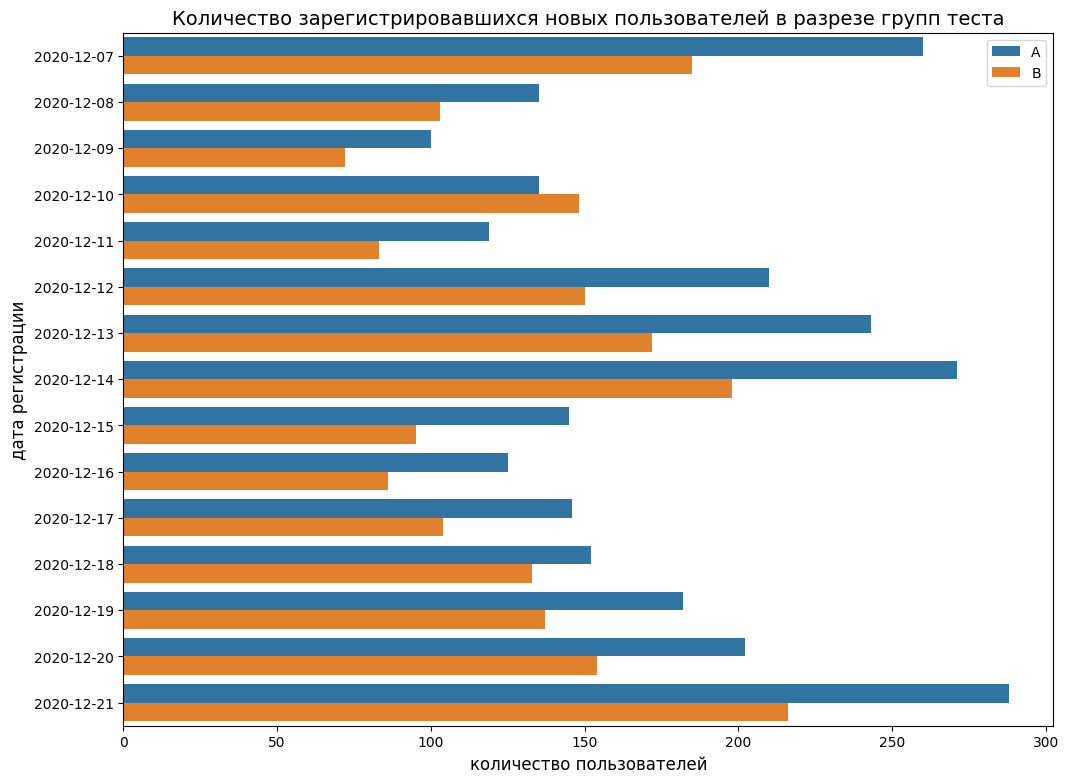

In [40]:
# визуализация численности новых пользователей в разрезе тестовых групп
merged_users_agg = merged_df.groupby(['registration_date', 'group']).agg({'user_id':'nunique'}).reset_index()
merged_users_agg['registration_date'] = pd.to_datetime(merged_users_agg['registration_date'], errors='ignore').dt.date

plt.figure(figsize=(12, 9))
sns.barplot(data=merged_users_agg, y='registration_date', x='user_id', hue='group')
ax = plt.gca()
plt.title('Количество зарегистрировавшихся новых пользователей в разрезе групп теста', fontsize=14)
ax.set_ylabel('дата регистрации', fontsize=12)
ax.set_xlabel('количество пользователей', fontsize=12)
plt.legend();

Итак, мы определили, что общее количество участников теста составляет 5 099 человек. Хватит ли этого объёма для проведения A/B-тестирования длительностью 14 дней? Для расчёта необходимого размера тестовой группы можно использовать следующую формулу:

$$ n = \left(Z_{\frac{\alpha}{2}} + Z_{\beta}\right)^2 \cdot \frac{{p_1 \cdot (1 - p_1) + p_2 \cdot (1 - p_2)}}{{(p_1 - p_2)^2}} $$, где:

$n$ - минимальный размер тестовой группы B
<br>$Zα/2$ - критическое значение стандартного нормального распределения для выбранного уровня значимости α/2
<br>$Zβ$ - критическое значение стандартного нормального распределения для выбранной статистической мощности 1-β
<br>$p_1$ - ожидаемая конверсия в группе A
<br>$p_2$ - ожидаемая конверсия в группе B

Или прибегнуть к наиболее распространённому инструменту - статистическому калькулятору, к примеру, таким: "Калькулятор достоверности проведения A/B-тестирования" https://mindbox.ru/tools/ab-test-calculator/.

<img src="https://i.imgur.com/UoCDnPz.jpg">

Приблизительно такие же числовые характеристики в <a href="https://www.evanmiller.org/ab-testing/sample-size.html#!30;95;5;10;0">абсолютных</a> и <a href="https://www.evanmiller.org/ab-testing/sample-size.html#!30;95;5;10;0">относительных</a> показателях дают результаты калькулятора https://www.evanmiller.org/ab-testing/sample-size.

Следовательно, имеющиеся в нашем распоряжении выборки дадут статистически достоверный результат. 

**Вывод:** на текущий момент мы можем отметить ещё одно несоответствие ТЗ в части ожидаемого количества участников теста: итоговое количество участников составляет 5099 человек, что на 901 человек меньше заявленного (в относительных значениях разница составляет порядка 15%). Численно контрольная группа А незначительно больше экспериментальной группы B на 707 человек или 13.86%.

<a id=3.5></a>
#### 3.5. Установление соответствия результатов теста ожидаемому эффекту
Ожидаемый эффект: за 14 дней с момента регистрации в системе пользователи покажут улучшение каждой метрики не менее, чем на `10%`, а именно: 
* конверсии в просмотр карточек товаров — событие `product_page`;
* просмотры корзины — `product_cart`;
* покупки — `purchase`.

In [41]:
# объединение датафреймов: соединение данных пользователь - действия пользователя
merged_df = pd.merge(merged_df, users_events, on='user_id', how='left')
merged_df = merged_df.drop('ab_test', axis=1)

In [42]:
# в работу запускаем копийный датафрейм
df = merged_df.copy()

In [43]:
# необходимое преобразование типов данных
df['event_date'] = pd.to_datetime(df['event_date'], errors='ignore').dt.date
df['event_date'] = pd.to_datetime(df['event_date'])
df['event_time'] = pd.to_datetime(df['event_time'], format='%H:%M:%S', errors='ignore').dt.time

In [44]:
# проверка результата преобразования
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21115 entries, 0 to 21114
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            21115 non-null  object        
 1   group              21115 non-null  object        
 2   registration_date  19681 non-null  datetime64[ns]
 3   region             19681 non-null  object        
 4   device             19681 non-null  object        
 5   event_dateNtime    18804 non-null  datetime64[ns]
 6   event_name         18804 non-null  object        
 7   details            2483 non-null   float64       
 8   event_date         18804 non-null  datetime64[ns]
 9   event_time         18804 non-null  object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 1.6+ MB


In [45]:
# пересобираем порядок столбцов
df = df[['user_id', 'group', 'registration_date', 'device', 'event_name', 'details', 'event_dateNtime', 'event_date', 'event_time']]
df.head()

,user_id,group,registration_date,device,event_name,details,event_dateNtime,event_date,event_time
0,D1ABA3E2887B6A73,A,2020-12-07,PC,purchase,99.99,2020-12-07 14:43:27,2020-12-07,14:43:27
1,D1ABA3E2887B6A73,A,2020-12-07,PC,purchase,4.99,2020-12-25 00:04:56,2020-12-25,00:04:56
2,D1ABA3E2887B6A73,A,2020-12-07,PC,product_cart,NaN,2020-12-07 14:43:29,2020-12-07,14:43:29
3,D1ABA3E2887B6A73,A,2020-12-07,PC,product_cart,NaN,2020-12-25 00:04:57,2020-12-25,00:04:57
4,D1ABA3E2887B6A73,A,2020-12-07,PC,product_page,NaN,2020-12-07 14:43:27,2020-12-07,14:43:27


Мы создали один большой датафрейм `df` с полными общими данными по пользователям исследуемого A/B-тестирования. Создадим сводную таблицу `events`, где мы сгруппируем данные по группам A/B-теста в разрезе совершаемых событий к котормы мы добавим общее количество пользователей в каждой группе.

In [46]:
# группировка данных по количеству пользователей и их действиям
events = df.pivot_table(index='group', columns='event_name', values='user_id', aggfunc='nunique')
events['registration'] = ''
events.loc[events.index == 'A', 'registration'] = df[df.group == "A"]['user_id'].nunique()
events.loc[events.index == 'B', 'registration'] = df[df.group == "B"]['user_id'].nunique()
events = events[['registration', 'login', 'product_page', 'product_cart', 'purchase']].reset_index()
events

event_name,group,registration,login,product_page,product_cart,purchase
0,A,2903,2082,1360,631,652
1,B,2196,706,397,195,198


Визуальное знакомство с данными по этапам воронки событий в каждой группе указывает нам на некоторое число пользователей, которые залогинились в системе, но не совершили ни одного действия. Самый большой провал значений между регистрацией и логированием в системе отмечается в группе B. Ещё одна интересная особенность заключается в количественном превосходстве значений между покупкой и просмотром корзины, следовательно, на сайте реализована функция моментальной покупки в один клик.

Посмотрим на воронку событий по каждой группе и после этого детально посчитаем потери в каждой группе.

In [47]:
# создаём таблицу для визуализации воронки событий в разрезе тестовых групп
funnel_groups = (df.groupby(['event_name', 'group']).agg({'user_id': 'nunique'}).reset_index().\
rename(columns={'user_id' : 'total_users'}).sort_values(by=['group', 'total_users'], ascending=False))
funnel_groups = funnel_groups.reindex([1,5,3,7,0,4,2,6]).reset_index(drop=True)
funnel_groups

,event_name,group,total_users
0,login,B,706
1,product_page,B,397
2,product_cart,B,195
3,purchase,B,198
4,login,A,2082
5,product_page,A,1360
6,product_cart,A,631
7,purchase,A,652


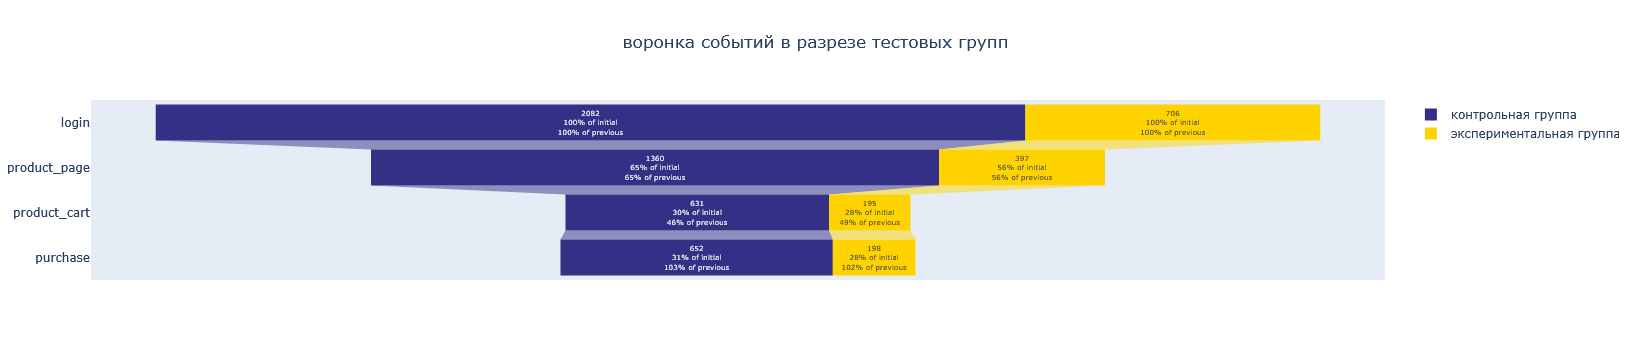

In [48]:
# воронка событий в разрезе тестовых групп
fig = go.Figure()
fig.add_trace(go.Funnel(name = 'контрольная группа',
                        y = funnel_groups.query('group == "A"')['event_name'],
                        x = funnel_groups.query('group == "A"')['total_users'],
                        textposition = 'inside',
                        textinfo = 'value+percent previous+percent initial'))

fig.add_trace(go.Funnel(name = 'экспериментальная группа',
                        y = funnel_groups.query('group == "B"')['event_name'],
                        x = funnel_groups.query('group == "B"')['total_users'],
                        textposition = 'inside',
                        textinfo = 'value+percent previous+percent initial'))

fig.update_layout(title={'text': 'воронка событий в разрезе тестовых групп', 
                         'xanchor': 'center', 'x':0.5, 'y':0.9}, 
                  colorway=['#333086', '#FFD300'])
fig.show()

In [49]:
# расчёт потерь пользователей на всех шагах воронки событий в абсолютных и относительных значениях в разрезе групп
funnel_groups['percent, %'] = funnel_groups['total_users'] / df['user_id'].nunique() * 100
funnel_groups['shift_users'] = (funnel_groups['total_users'].pct_change()+1).round(2)
funnel_groups['diff_users'] = (funnel_groups['total_users'].diff()).abs()
funnel_groups['shift_users_from_initial'] = (funnel_groups['total_users'].pct_change(periods = 3)+1).round(2)
funnel_groups.fillna(1, inplace = True)
funnel_groups.reset_index
funnel_groups

,event_name,group,total_users,"percent, %",shift_users,diff_users,shift_users_from_initial
0,login,B,706,13.85,1.00,1.00,1.00
1,product_page,B,397,7.79,0.56,309.00,1.00
2,product_cart,B,195,3.82,0.49,202.00,1.00
3,purchase,B,198,3.88,1.02,3.00,0.28
4,login,A,2082,40.83,10.52,1884.00,5.24
5,product_page,A,1360,26.67,0.65,722.00,6.97
6,product_cart,A,631,12.37,0.46,729.00,3.19
7,purchase,A,652,12.79,1.03,21.00,0.31


**Вывод:** таким образом, на основании полученных расчётов мы можем утверждать, что требование технического задания относительно улучшения каждой метрики не менее, чем на 10%, а именно: конверсии в просмотр карточек товаров — событие `product_page`, просмотры корзины — `product_cart`, покупки — `purchase` не выполняются по всем метрикам.

Обобщённые итоги проверки имеющихся данных на соответствие техническому заданию представлены в таблице ниже:

|№ п/п|Наименование условия технического задания|выполняется|не выполняется|
|-----|:----------------------------------------|-----------|--------------|
|1.|Наличие двух групп тестирования: А (контрольная), B (новая платёжная воронка)|+||
|2.|Дата запуска: 2020-12-07|+||
|3.|Дата остановки набора новых пользователей: 2020-12-21|+||
|4.|Дата остановки: 2021-01-04||+|
|5.|Аудитория: 15% новых пользователей из региона EU||+|
|6.|Ожидаемое количество участников теста: 6000||+|
|7.|Ожидаемый эффект: за 14 дней с момента регистрации в системе <br>пользователи покажут улучшение каждой метрики не менее, чем на 10%, а именно: <br>конверсии в просмотр карточек товаров — событие `product_page`, <br>просмотры корзины — `product_cart`, <br>покупки — `purchase`||+|

Соотношение количества выполненных и невыполненных пунктов технического задания в пропорции 3:4 подводит нас к мысли о некорректном подходе к проведению тестирования.

<br>[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6)

In [50]:
# количество строк в массиве данных до фильтрации по лайфтайму 14 дней
len(df)

21115

In [51]:
# количество строк в массиве данных после фильтрации по лайфтайму 14 дней
df = df[(df['registration_date'] + timedelta(days=13)) >= df['event_date']]
len(df)

16918

<a id=4></a>
### Шаг 4. Исследовательский анализ данных

<a id=4.1></a>
#### 4.1. Сколько всего событий в логе и как часто они происходят?

In [52]:
# количество типов событий в логе
print('Всего типов событий в логе:', df['event_name'].nunique())

# количество событий в логе в разрезе каждого типа
events_log = df.groupby('event_name').agg({'event_name': 'count'})
events_log = events_log.reindex(['login', 'product_page', 'product_cart', 'purchase'])
events_log

Всего типов событий в логе: 4


,event_name
event_name,
login,7617
product_page,4746
product_cart,2278
purchase,2277


In [53]:
# частота событий в период проведения теста
df.groupby('event_date').agg({'event_name':'count'})

,event_name
event_date,
2020-12-07,489
2020-12-08,408
2020-12-09,532
2020-12-10,428
2020-12-11,379
2020-12-12,423
2020-12-13,336
2020-12-14,948
2020-12-15,944


Частота событий представляет собой отношение количества событий к продолжительности определённого периода, к примеру, одного дня.

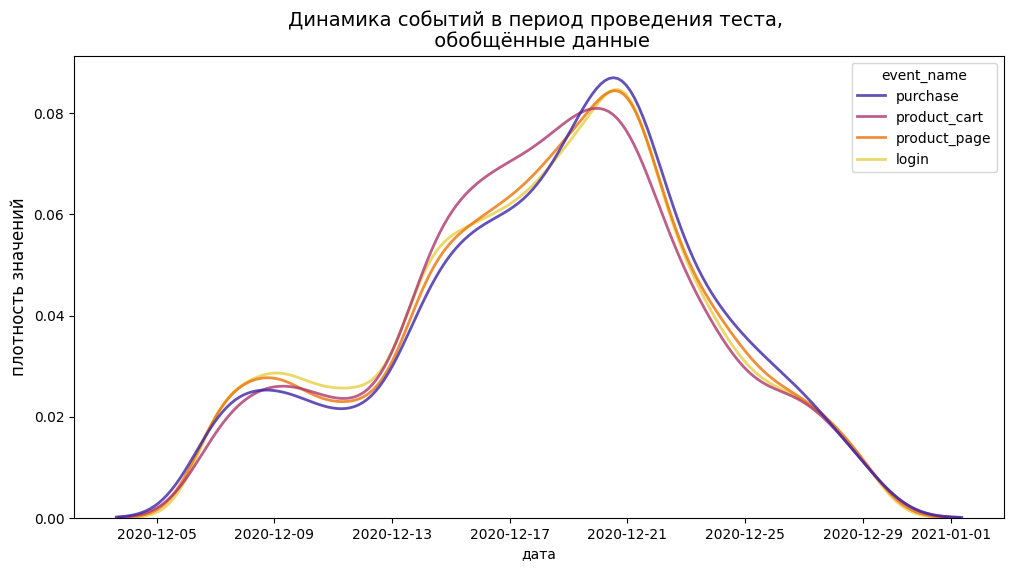

In [54]:
# динамика интенсивности событий в период проведения теста 
plt.figure(figsize=(12,6))
sns.kdeplot(data=df, x='event_date', hue='event_name', common_norm=False, palette='CMRmap', alpha=0.8, linewidth=2)
plt.title('Динамика событий в период проведения теста, \n обобщённые данные', fontsize=14)
plt.ylabel('плотность значений', fontsize=12)
plt.xlabel('дата')
plt.show();

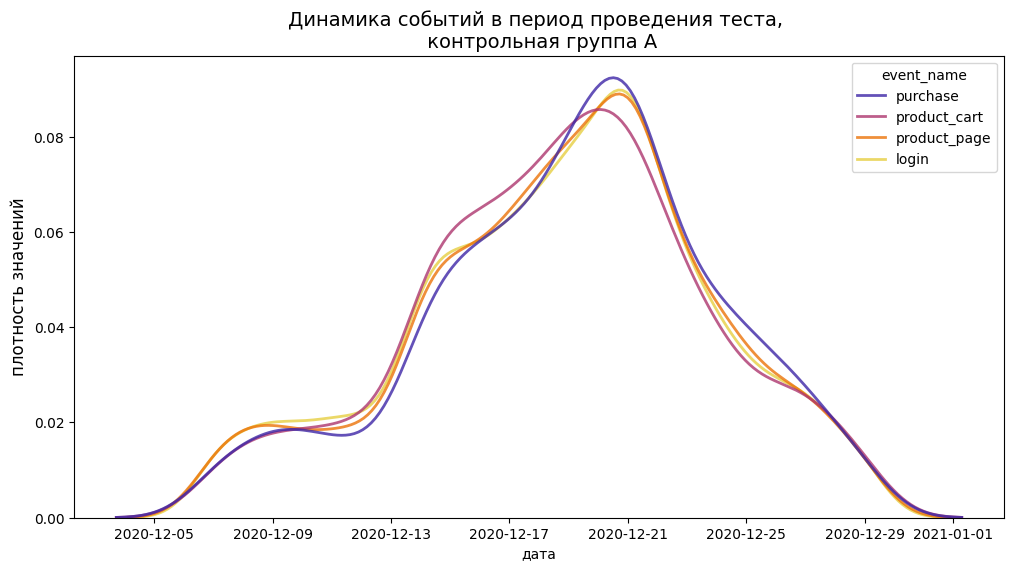

In [55]:
# динамика интенсивности событий в период проведения теста 
plt.figure(figsize=(12,6))
sns.kdeplot(data=df.query('group=="A"'), x='event_date', hue='event_name', common_norm=False, palette='CMRmap', alpha=0.8, linewidth=2)
plt.title('Динамика событий в период проведения теста, \n контрольная группа А', fontsize=14)
plt.ylabel('плотность значений', fontsize=12)
plt.xlabel('дата')
plt.show();

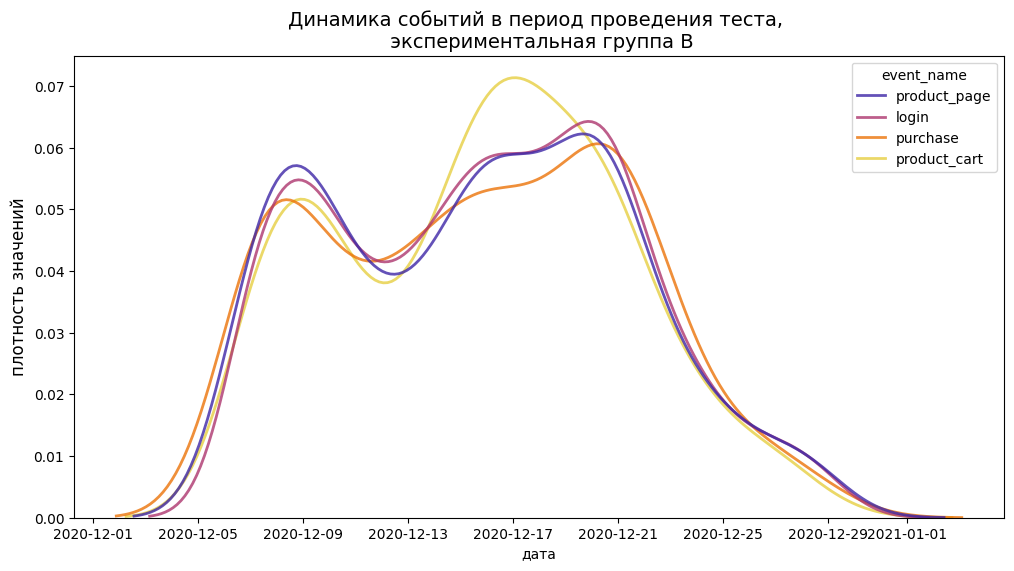

In [56]:
# динамика интенсивности событий в период проведения теста 
plt.figure(figsize=(12,6))
sns.kdeplot(data=df.query('group=="B"'), x='event_date', hue='event_name', common_norm=False, palette='CMRmap', alpha=0.8, linewidth=2)
plt.title('Динамика событий в период проведения теста, \n экспериментальная группа B', fontsize=14)
plt.ylabel('плотность значений', fontsize=12)
plt.xlabel('дата')
plt.show();

**Вывод:** на этапе подготовки данных мы уже получили некоторые сведения по этому вопросу, остаётся только уточнить. Всего в рабочем отфильтрованном по параметрам технического задания массиве данных имеется 4 уникальных типа событий, а именно:
* `login` - логирование в системе;
* `product_cart` - просмотр корзины товаров;
* `product_page` - просмотр карточки товара;
* `purchase` - покупка товара.

Всего пользователями теста совершено 16 918 события. Ожидаемо, самое массовое событие — логирование в системе (7 617 строка), самое редкое — покупка (2 277 строки).

Пиковая нагрузка по событийности приходится на период с 14 декабря по 22 декабря 2020 года, что находит объяснение в общеевропейском календаре. На указанный период приходится традиционное начало рождественских сейлов в Европе, тут мы можем отметить ещё одну интересную закономерность пользовательского поведенния, связанную с самой сутью тестирования. 

Контрольная группа с оригинальной версией сайта по-старинке совершает большое количество переходов по страницам сайта в то время как экспериментальная группа с улучшенной рекомендательной системой в разы сокращает своё время пребывания на сайте и в несколько раз быстрее по рекомендациям "выходит" на искомый продукт и покупает его напрямую с карточки товара - взвешенное отношение к покупкам появляется вновь только после 20 декабря 2020 года.

<a id=4.2></a>
#### 4.2. Сколько всего пользователей и сколько в среднем событий приходится на пользователя?

In [57]:
# количество пользоваетелей
print('Всего пользователей:', df['user_id'].nunique())

Всего пользователей: 2594


In [58]:
# количество пользователей в разерезе групп, а также количество строк данных в разрезе групп
df.groupby('group').agg({'user_id': ('nunique', 'count')})

user_id       
      nunique  count
group               
A        1939  13374
B         655   3544

In [59]:
# расчёт среднего количества событий на пользователя
df.shape[0] / df['user_id'].nunique()

6.521973785659213

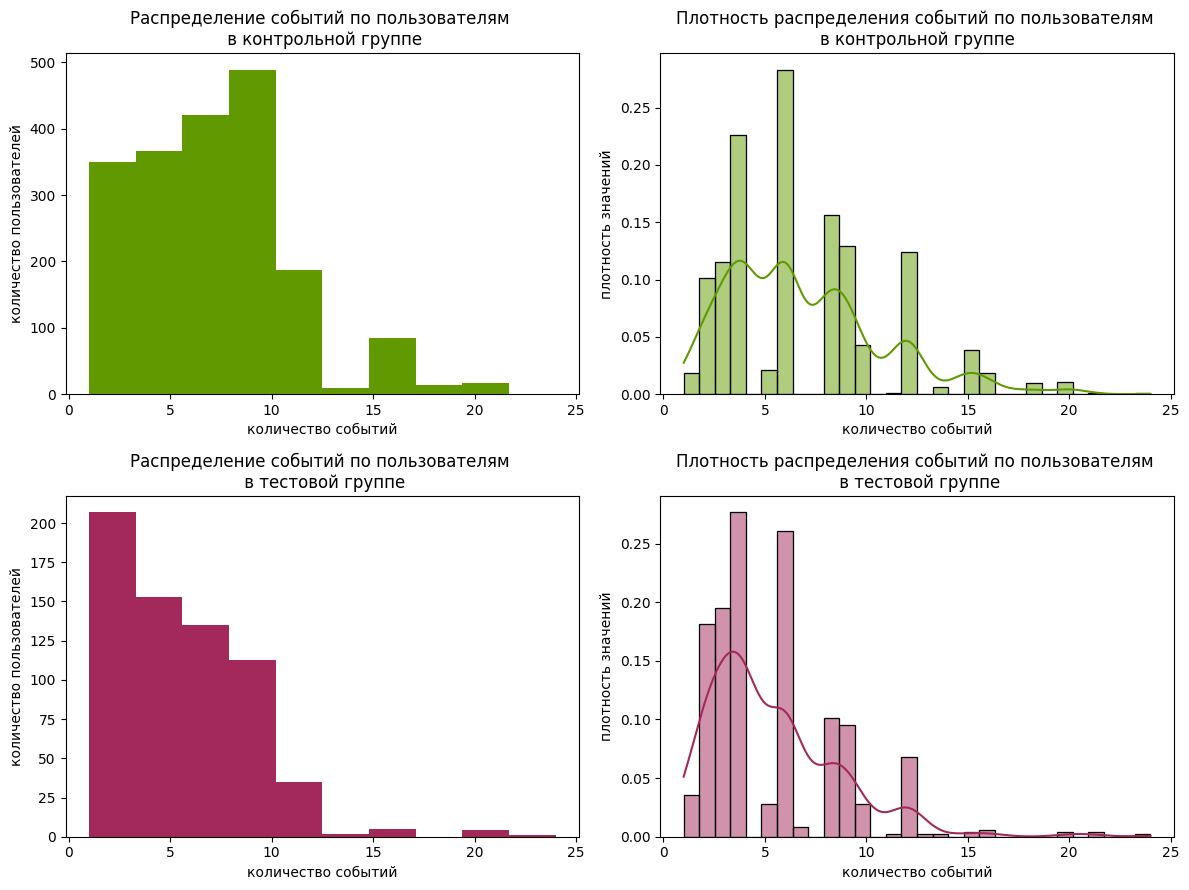

In [60]:
# парные диаграммы для количества событий на пользователя
events_by_user_A = df.query('group=="A"').groupby('user_id').agg(event_count=('event_name', 'count')).reset_index()
events_by_user_B = df.query('group=="B"').groupby('user_id').agg(event_count=('event_name', 'count')).reset_index()

fig, axs = plt.subplots(2, 2, figsize=(12, 9))

# массив с данными для каждого графика
# [название графика, данные, цвет]
plot_data = [
    ['Распределение событий по пользователям \n в контрольной группе', events_by_user_A['event_count'], '#619A00'],
    ['Плотность распределения событий по пользователям \nв контрольной группе', events_by_user_A['event_count'], '#619A00'],
    ['Распределение событий по пользователям \n в тестовой группе', events_by_user_B['event_count'], '#A4295B'],
    ['Плотность распределения событий по пользователям \n в тестовой группе', events_by_user_B['event_count'], '#A4295B']]

# цикл для создания и настройки каждого графика
for i, ax in enumerate(axs.flat):
    title, data, color = plot_data[i]

    ax.set_title(title)
    if i % 2 == 0:
        ax.hist(data, color=color)
        ax.set_ylabel('количество пользователей')
    else:
        sns.histplot(data, color=color, kde=True, bins=30, common_norm=False, stat='density', ax=ax)
        ax.set_ylabel('плотность значений')

    ax.set_xlabel('количество событий')

plt.tight_layout()
plt.show()

In [61]:
# первичная описательная статистика количества событий на пользователя
groups = ['group_A', 'group_B']
statistics = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'median', '95%', '99%']

stat = pd.DataFrame(index=statistics)

for group in groups:
    events_by_user = events_by_user_A if group == 'group_A' else events_by_user_B
    
    stat_group = events_by_user['event_count'].describe().to_frame()
    stat_group.loc['median'] = events_by_user['event_count'].median()
    stat_group.loc['95%'] = events_by_user['event_count'].quantile(0.95)
    stat_group.loc['99%'] = events_by_user['event_count'].quantile(0.99)
    stat_group = stat_group.rename(columns={'event_count': group})
    
    stat = stat.merge(stat_group, left_index=True, right_index=True)

stat = stat.astype(int)
display('Описательные статистики количества событий на пользователя в разрезе групп:')
stat

'Описательные статистики количества событий на пользователя в разрезе групп:'

,group_A,group_B
count,1939,655
mean,6,5
std,3,3
min,1,1
25%,4,3
50%,6,4
75%,9,6
max,24,24
median,6,4
95%,15,12


In [62]:
print('Аномальных пользователей с порогом выше Q99 в контрольной группе:', len(events_by_user_A[events_by_user_A['event_count'] > 18]))
print('Аномальных пользователей с порогом выше Q99 в экспериментальной группе:', len(events_by_user_B[events_by_user_B['event_count'] > 16]))
print('Относительное значение фанатов сайта:', (22+18) / df.user_id.nunique())

Аномальных пользователей с порогом выше Q99 в контрольной группе: 18
Аномальных пользователей с порогом выше Q99 в экспериментальной группе: 5
Относительное значение фанатов сайта: 0.015420200462606014


**Вывод:** общее количество пользователей составляет 2 594 человек, в том числе 1 939 пользователей в контрольной группе и 655 пользователей в экспериментальной группе. Активность пользователей в двух тестовых группах представлена неравномерно, численное преимущество за пользователями контрольной группы, они совершили почти в три раза больше взаимодействий с сайтом, чем пользователи группы с улучшенной рекомендательной системой. Казалось бы, это тревожный сигнал. Однако, если посмотреть на сложившуюся ситуацию через призму сокращения количества действий пользователя при сохранении того же уровня конверсии в покупку, то такая разница значений может быть выгодной, и этот вопрос мы изучим далее в исследовании.

В среднем на одного пользователя вне признака группы приходится 6 события, в группе А это значение равно 6, в группе B - 5. С учётом аномальных значений, медиана указывает на 6 значений на пользователя в группе А, а в группе B - 4. Как таковых фанатов сайта мало, всего по обеим группам 23 человек, или 0.015% всех пользователей.

In [63]:
# расчёт количества событий по пользователям
df.groupby('user_id').agg(event_count=('event_name', 'count')).value_counts().to_frame()

,count
event_count,
6,552
4,475
8,284
3,270
2,242
9,240
12,219
10,78
15,59


Очевидно, после удаления событий с лайфтаймом более 14 дней, из данных выбыли все строки без событий. Описательные статистики по событиям в разрезе групп тестирования также указывают на минимальное количество событий, равное единице.

<a id=4.3></a>
#### 4.3. Распределение событий по пользователям: обобщённые и групповые данные

In [64]:
# описательные статистики по времени
df['event_dateNtime'].describe()

count                            16918
mean     2020-12-18 17:22:58.844485120
min                2020-12-07 00:16:00
25%      2020-12-15 07:35:40.249999872
50%                2020-12-19 06:31:07
75%                2020-12-22 05:06:08
max                2020-12-29 23:38:29
Name: event_dateNtime, dtype: object

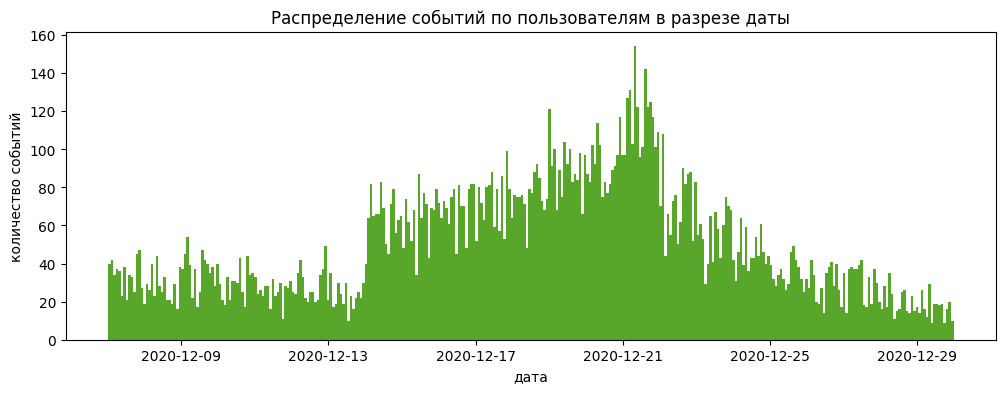

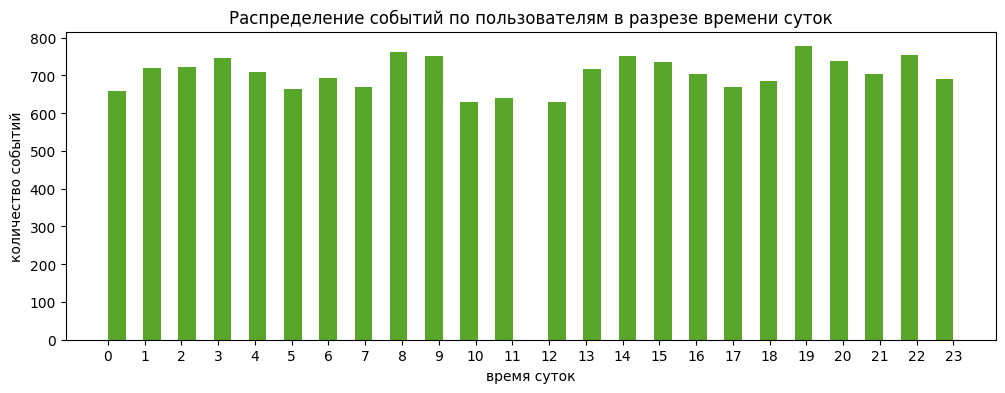

In [65]:
# общие данные
# гистограмма активности пользователей в разрезе даты
plt.figure(figsize=(12,4))
plt.title('Распределение событий по пользователям в разрезе даты')
df['event_dateNtime'].hist(grid=False, color='#58A72A', bins=14*24, xrot=0).set(ylabel='количество событий', xlabel='дата')

# гистограмма активности пользователей в разрезе времени суток
plt.figure(figsize=(12,4))
plt.title('Распределение событий по пользователям в разрезе времени суток')
df['event_dateNtime'].dt.hour.hist(grid=False, color='#58A72A', bins=48).set(ylabel='количество событий', xlabel='время суток')
plt.xticks(range(0, 24))
plt.show()

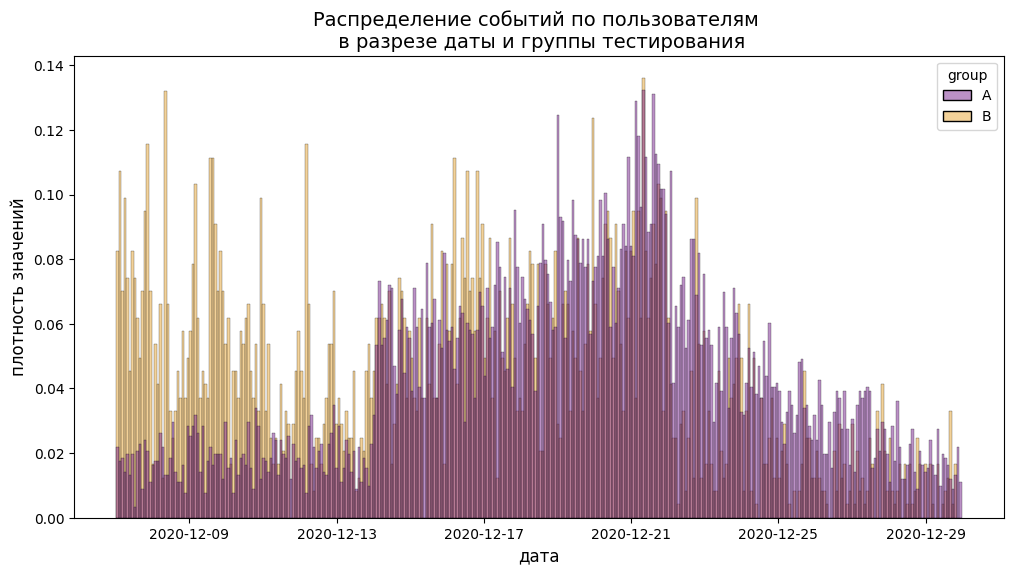

In [66]:
# данные по группам 
# гистограмма активности пользователей в разрезе даты
plt.figure(figsize=(12,6))
plt.title('Распределение событий по пользователям \n в разрезе даты и группы тестирования', fontsize=14)
sns.histplot(data=df, x='event_dateNtime', hue='group', stat='density', bins=14*24, common_norm=False,
                 palette=['#79248f', '#e9a735'])
plt.ylabel('плотность значений', fontsize=12)
plt.xlabel('дата', fontsize=12)
plt.show();

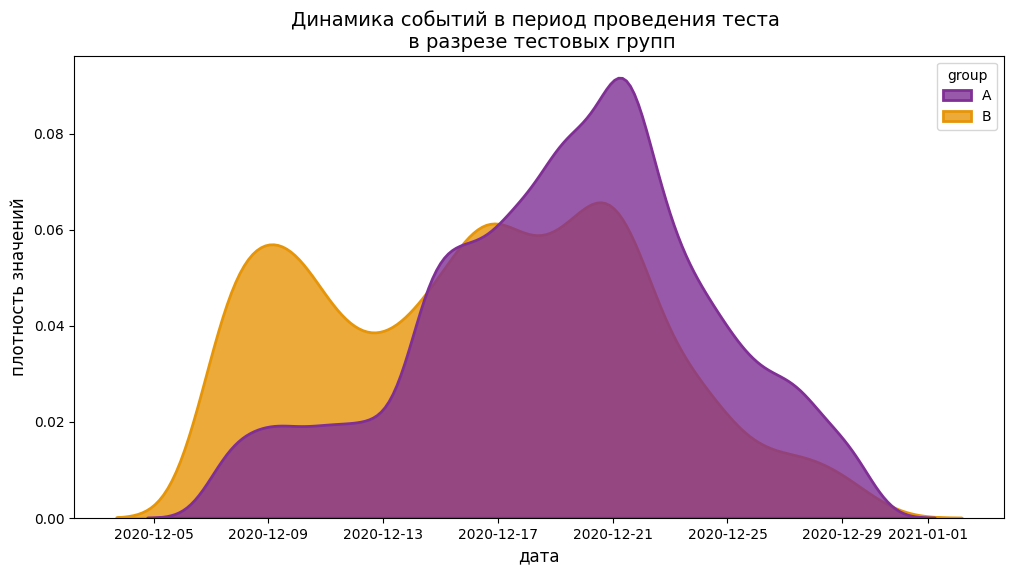

In [67]:
# динамика интенсивности событий в период проведения теста 
plt.figure(figsize=(12,6))
sns.kdeplot(data=df, x='event_dateNtime', hue='group', common_norm=False, fill=True, palette='CMRmap', alpha=0.8, linewidth=2)
plt.title('Динамика событий в период проведения теста \n в разрезе тестовых групп', fontsize=14)
plt.ylabel('плотность значений', fontsize=12)
plt.xlabel('дата', fontsize=12)
plt.show();

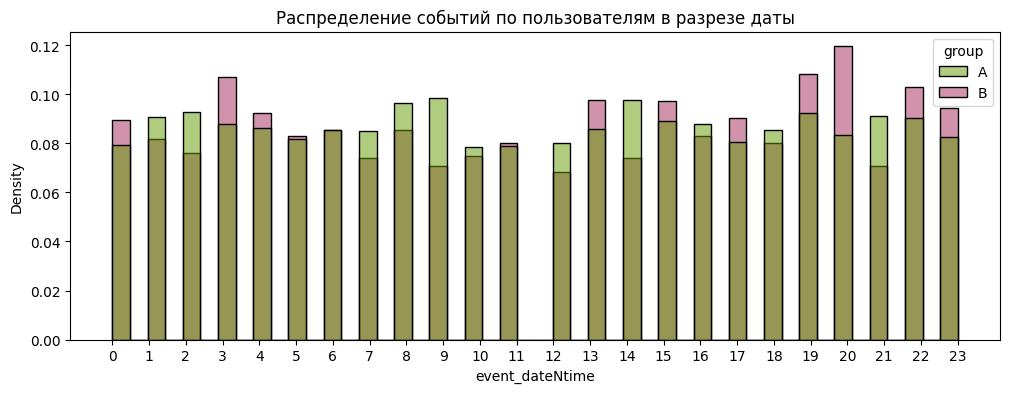

In [68]:
# данные по группам 
# гистограмма активности пользователей в разрезе даты
plt.figure(figsize=(12,4))
plt.title('Распределение событий по пользователям в разрезе даты')

sns.histplot(data=df, x=df['event_dateNtime'].dt.hour, hue='group', stat='density', bins=48, common_norm=False,
                 palette=['#619A00', '#A4295B'])
plt.xticks(range(0, 24))
plt.show()

In [69]:
# частота событий в пиковый период проведения теста
peak_A = df.query('group=="A"').groupby(['event_date', 'event_name']).agg({'event_name':'count'})[24:64]
peak_B = df.query('group=="B"').groupby(['event_date', 'event_name']).agg({'event_name':'count'})[24:64]
peak_A = peak_A.rename(columns={'event_name': 'peak_A'})
peak_B = peak_B.rename(columns={'event_name': 'peak_B'})
peak = peak_A.merge(peak_B, left_index=True, right_index=True)

In [70]:
# типология событий в пиковый период проведения теста
peak.style.background_gradient(subset = ['peak_A', 'peak_B'], cmap='crest')

**Вывод:** на основании информации датафрейма `df`, полученной методом `describe()`, а также с помощью гистограммы нами сформированы данные о распределении количества событий на отрезке времени с 10 по 30 декабря 2020 года включительно. Установлен факт неравнромерного распределения хронологических данных: значения признка на отрезке с 14 по 22 декабря 2020 года включительно присуствуют в больших количествах.

На графиках по обобщённым данным мы видим тенденцию динамичного роста количества событий на отрезке с 14 по 22 декабря 2020 года включительно. При рассмотрении поведения пользователей в разрезе контрольной и экспериментальной групп становится очевидным общий характер взаимодействия с сайтом: резко возрастает количество логирований в системе и просмотр товаров на сайте. И если на начальном этапе тестирования соотношение логирований в группах выражалось отношением 1:2 (в пользу контрольной группы А), то по мере нарастания активности пользователей к 22 числу отношение изменилось до 1:6 (по-прежнему в пользу контрольной группы А). Предполагаем, что это могло быть следствием таргетированной рекламной акции: в следующем тематическом блоке мы видим на отметках этого периода всплеск в данных по типу устройств `iPhone` и `PC`. Поскольку, мы не имеем достоверной информации о характере товаров сайта, то можем предположить, что это могли быть сезонные предложения, связанные с самой техникой: приложения, компьютерные или мобильные игры со скидкой именно для этих типов устройв.

Также установлено равномерное присутствие пользователей на сайте в тчение суток. Небольшие пики активности отмечаются в 8-9 утра, 14 часов дня и 19 часов вечера, что связано с устоявшимся графиком работы. Также, пользователи охотно совершают покупки на сон грядущий в 22 часа вечера. Минимальная нагрузка на сайт приходится на 11-12 часов утра. 

<a id=4.4></a>
#### 4.4. Пользовательские девайсы, их представленность и ретроспектива использования

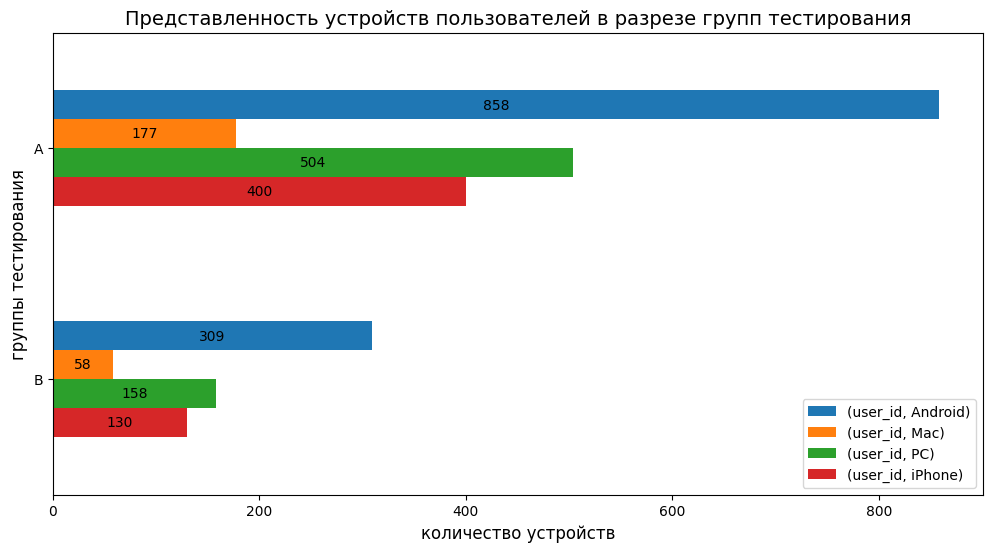

In [71]:
# расчёт и визуализация количества типов устройств пользователей в группах теста
users_dev = df.groupby(['group', 'device']).agg({'user_id':'nunique'}).unstack()
ax = users_dev.plot(kind='barh', figsize=(12,6))

plt.title('Представленность устройств пользователей в разрезе групп тестирования', fontsize=14)
plt.xlabel('количество устройств', fontsize=12)
plt.ylabel('группы тестирования', fontsize=12)
ax.invert_yaxis()

for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        x = p.get_x() + width / 2
        y = p.get_y() + height / 2
        count = f'{width:.0f}'
        plt.annotate(count, (x, y), xytext=(0, 0), textcoords='offset points', ha='center', va='center')

plt.legend()
plt.show()

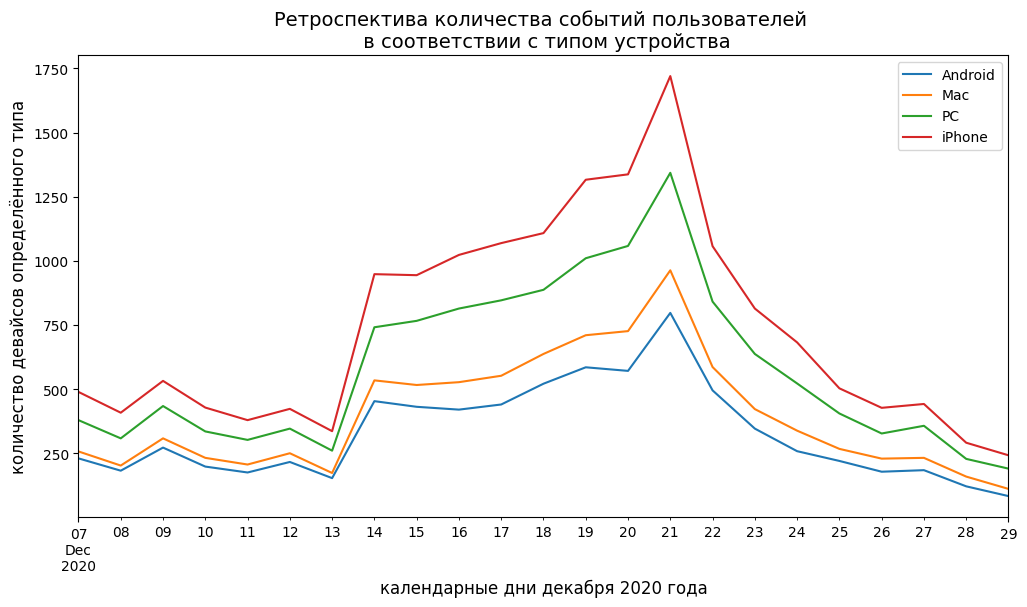

In [72]:
# расчёт и визуализиация динамики использования того или иного типа устройства
fig, ax = plt.subplots(figsize=(12,12))
df.pivot_table(index='device', columns='event_date', values='user_id', aggfunc='count').\
fillna(0).T.plot(kind='line', stacked=True, ax=ax, figsize=(12,6))
ax.legend(bbox_to_anchor=(1.0, 1.0))
ax.set_xlabel('календарные дни декабря 2020 года', fontsize=12)
ax.set_ylabel('количество девайсов определённого типа', fontsize=12)
ax.set_title('Ретроспектива количества событий пользователей \n в соответствии с типом устройства', fontsize=14)
plt.show()

**Вывод:** численное превосходство характерно для `Android`, однако, хоть этот тип устройств и самый массовый, им пользуются реже всего. Сбалансированное второ место по численности занимает `PC`, и тут всё склоадывается благополучно - этим типом устройств пользуются довольно много и часто в обеих группах. Третье место по численности, но первое по частоте использования относится к типу устройств `iPhone`. Даже только на основании этой тройки лидеров мы можем с довольно большой уверенностью сказать, что сайт магазина имеет кросс-платформенный характер и отлично адаптирован как под персональные компьютеры, так и под смартфоны. Последняя строчка рейтинга достаётся персональным компьютерам системы `Mac` - они представлены наименьшим числом пользователей в обеих группах, однако по частоте использования занимают почётное третье место.

<a id=4.5></a>
#### 4.5. Оценка пользовательской активности

#### Оценка пользовательской активности: количество уникальных пользователей за сутки

In [73]:
# DAU
df.groupby('event_date').agg({'user_id': 'nunique'})

,user_id
event_date,
2020-12-07,222
2020-12-08,190
2020-12-09,245
2020-12-10,202
2020-12-11,187
2020-12-12,203
2020-12-13,170
2020-12-14,434
2020-12-15,422


In [74]:
# расчёт среднего значения DAU
dau_total = (df.groupby('event_date').agg({'user_id': 'nunique'}).mean())
dau_total

user_id   331.43
dtype: float64

**Вывод:** оценка пользовательской активности как таковая помогает лучше понять характер взаимодействия пользователей с сайтом. Так, максимальное количество уникальных посетителей в сутки характерно для пика предрождественских сейлов 19-21 декабря 2020 года включительно и составляет порядка 620-840 человек в сутки. В остальные дни до и после в среднем на сайт заходят ежедневно порядка 350 человек. 

#### Оценка пользовательской активности: количество уникальных пользователей за неделю

In [75]:
# создание признака недели
df['event_week'] = df['event_dateNtime'].dt.isocalendar().week

# вывод полученных значений
df.event_week.unique()

<IntegerArray>
[50, 51, 52, 53]
Length: 4, dtype: UInt32

In [76]:
# WAU
df.groupby(['event_week']).agg({'user_id': 'nunique'})

,user_id
event_week,
50,727
51,1881
52,1411
53,231


In [77]:
# расчёт среднего значения WAU
wau_total = (df.groupby(['event_week']).agg({'user_id': 'nunique'}).mean())
wau_total

user_id   1062.50
dtype: float64

**Вывод:** за неделю сайт посещает в среднем 1200 уникальных пользователей. Ожидаемо, наибольший наплав посетителей отмечается в период с 14 по 20 декабря 2020 года. Со следующей недели значение начинает несущественно падать.

#### Оценка пользовательской активности: недельный sticky factor

In [78]:
# расчёт sticky factor в процентах по отношению к недельной аудитории
dau_total / wau_total * 100

user_id   31.19
dtype: float64

**Вывод:** высокий процент «липучести» означает, что люди часто пользуются этим приложением. Чем выше лояльность, тем охотнее пользователи рекомендуют приложение друзьям и знакомым, тем больше прирост активной аудитории. Поскольку, показатель находится на достаточно низком уровне, мы можем говорить о том, что сайт не закрывает потребности пользователей, либо представленная на продажу продукция носит очень узкий и специфический характер.

#### Оценка пользовательской активности: медианное количество событий на пользователя

Благодаря DAU и WAU мы узнали, сколько пользователей заходят на сайт. Хорошо бы ещё выяснить, сколько времени они там проводят. К сожалению, в данных имеются только сведения о моменте совершения определённого действия. Медианное число событий на пользователя является показателем регулярности использования приложения, и это значение хорошо дополняет метрику `sticky factor`.

In [79]:
# количества событий на пользователя
ev = df.groupby('user_id').agg({'event_name':'count'})
print(ev['event_name'].describe())
print('Медианное значение: ', ev['event_name'].median())

# перцентили количества событий на одного пользователя
print('Q95 событий на пользователя', np.percentile(ev['event_name'], [95]))
print('Q99 событий на пользователя', np.percentile(ev['event_name'], [99]))
print('Аномальных пользователей с порогом выше Q99:', len(ev[ev['event_name'] > 16]))

count   2594.00
mean       6.52
std        3.75
min        1.00
25%        4.00
50%        6.00
75%        9.00
max       24.00
Name: event_name, dtype: float64
Медианное значение:  6.0
Q95 событий на пользователя [14.]
Q99 событий на пользователя [18.]
Аномальных пользователей с порогом выше Q99: 37


In [80]:
# частотность количества событий 
ev['event_name'].value_counts().to_frame()

,count
event_name,
6,552
4,475
8,284
3,270
2,242
9,240
12,219
10,78
15,59


**Вывод:** медианное количество событий на пользователя составляет 6 событий на человека. Одним событием на сайте пользователи не ограничиваются, чаще всего они совершают от 2 до 6 действий, реже от 8 до 12 действий. Увлечённых сёрферов совсем немного — всего 23 человека.

Чтобы узнать, в какое конкретно время пользователи наиболее активно пользуются сайтом, рассчитывают метрики `PCCU` и `ACU`.

### Оценка пользовательской активности: PCCU (Peak Concurrent User)
Она же PCU — максимальное число людей, единовременно находящихся на сайте. Измеряется за час, месяц или год. В нашем распоряжении данные за 2 недели, следовательно, мы можем рассчитать PCU за час. Зная, на какие часы приходится максимальное количество одномоментного присутствия пользователей в приложении, мы можем найти успешный момент публикации новой рекламной кампании, к примеру. В конечном итоге, эта метрика пользовательской активности и ранее рассчитанные матрики вовлечённости целевой аудитории помогут в перспективе улучшить финансовые показатели сайта.

In [81]:
# выделяем час
df['hour'] = df['event_dateNtime'].dt.hour

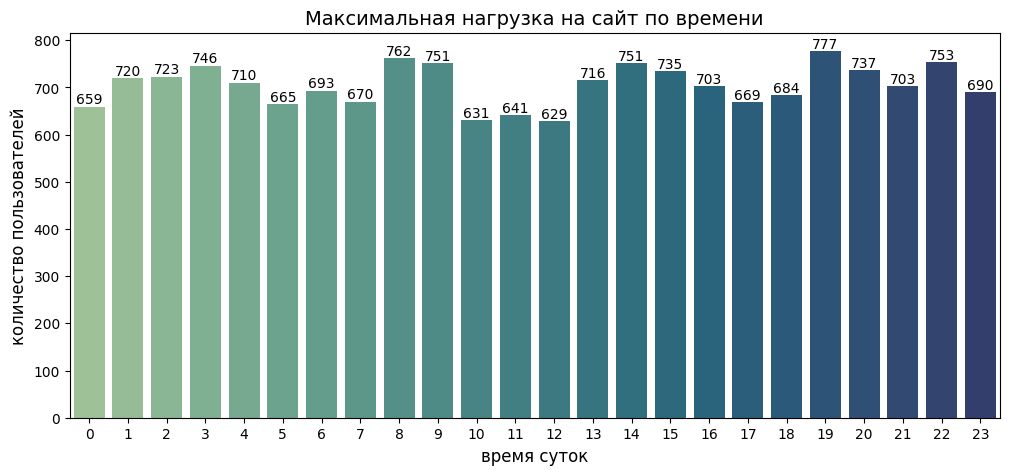

In [82]:
# расчёт пиковой нагрузки по времени
PCU = df.groupby('hour').agg({'user_id': 'count'}).sort_values(by='user_id', ascending=False)

# визуализируем частотность событий по пользователям
PCU = PCU.reset_index()
plt.figure(figsize=(12,5))
plt.title('Максимальная нагрузка на сайт по времени', size=14)
plots = sns.barplot(data=PCU, x='hour', y='user_id', estimator=np.sum, palette='crest')

for bar in plots.patches:
    plots.annotate(format(bar.get_height(), '.0f'), 
                   (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, 5), 
                   textcoords='offset points')

plt.ylabel('количество пользователей', fontsize=12)
plt.xlabel('время суток', fontsize=12)
plt.show()

In [83]:
# выделяем день недели
df['event_date'] = pd.to_datetime(df['event_date'])
df['day'] = df['event_date'].dt.strftime('%a')

In [84]:
# расчёт нагрузки на приложение в разрезе дня недели
df_day = df.groupby('day').agg({'user_id': 'nunique'}).sort_values(by='user_id', ascending=False).reset_index()
df_day = df_day.reindex([0,1,2,5,6,3,4]).reset_index(drop=True)

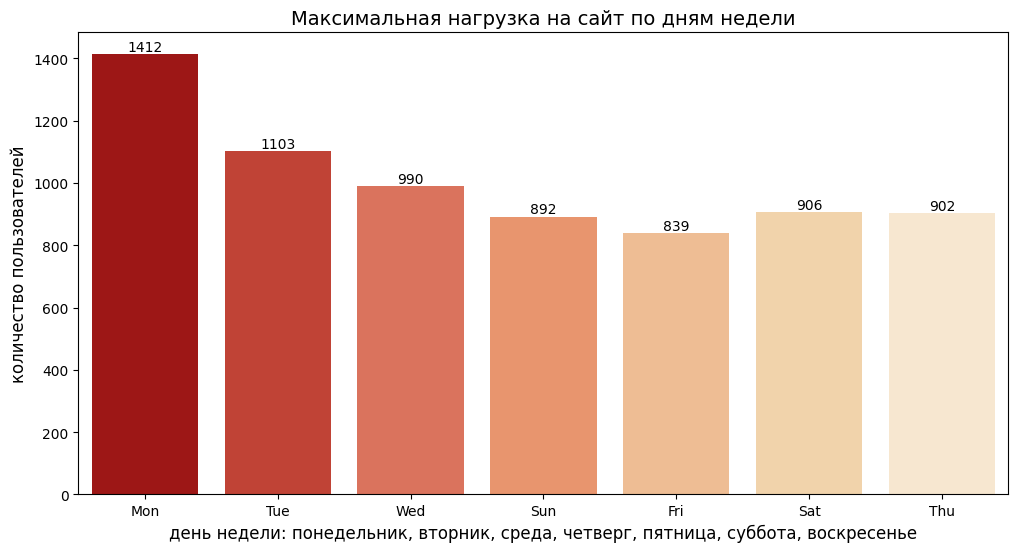

In [85]:
# визуализируем частотность событий по пользователям в разрезе дня недели
plt.figure(figsize=(12,6))
plt.title('Максимальная нагрузка на сайт по дням недели', fontsize=14)
plots = sns.barplot(data=df_day, x='day', y='user_id', palette='OrRd_r')
plt.ylabel('количество пользователей', fontsize=12)
plt.xlabel('день недели: понедельник, вторник, среда, четверг, пятница, суббота, воскресенье', fontsize=12)

for bar in plots.patches:
    plots.annotate(format(bar.get_height(), '.0f'), 
                   (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, 5), 
                   textcoords='offset points')

plt.show()

**Вывод:** метрика `PCCU` по часам и дням недели только подтверждает наши более ранние наблюдения. В день сайт загружен достаточно равномерно,  небольшие пики активности пользователей отмечаются в 8-9 утра, 14-15 часов, 19-22 часов вечера. Минимальная нагрузка на сайт отмечатеся в период с 10 до 12 часов утра.

Очень выразительную картину дают сведения о нагрузке на сайт в течение недели: с максимальных значений понедельника она плавно снижается к пятнице, при этом количество пользователей сокращается в 1,5 раза.

### Оценка пользовательской активности: ACU - Average Concurrent User

Среднее число Пользователей Онлайн — среднее количество пользователей, одновременно находящихся в приложении. Измеряется за конкретный промежуток времени: в час / день / неделю / месяц / год.

In [86]:
# ACU за час
df.groupby('hour').agg({'user_id': 'nunique'}).mean()

user_id   300.46
dtype: float64

In [87]:
# ACU за день (= среднее DAU)
df.groupby('event_date').agg({'user_id': 'nunique'}).mean()

user_id   331.43
dtype: float64

In [88]:
# ACU за неделю
df.groupby('event_week').agg({'user_id': 'nunique'}).mean()

user_id   1062.50
dtype: float64

**Вывод:** для более глубокого понимания процессов взаимодействия пользователей с продуктовым приложением, на наш взгляд, было необходимо рассчитать метрики DAU, WAU и Sticky factor. Именно этим бизнес-метрики оценивают пользовательскую активность и помогают понять владельцам бизнеса, сколько людей заинтересованы в их цифровом продукте.

Среднее количество уникальных пользователей в сутки составляет 331 человека, за неделю — 1062 человек, недельный фактор липучести составляет 31% процент, что определённо является тревожным сигналом. Высокий процент «липучести» означает, что люди часто пользуются этим приложением и с высокой вероятностью, они будуте рекомендовать его друзьям и знакомым, что в перспективе положительно повлияет на прирост активной аудитории. По значению этих метрик мы можем утверждать, что у сайта, конечно, есть своя аудитория, но над её расширением и удержанием ещё предстоит немало поработать.

В среднем онлайн за час могут присутствовать порядка 300 пользователей. Одномоментно за один час на сайте находятся от 700 до 777 пользователей. Нагрузка по времени суток распределена равномерно, существенных провалов не наблюдается. Самым ярким днём пользовательской активности является понедельник, ему немногим уступает вторник. Пользовательская активность убывает равномерно в течение всей недели.

На наш взгляд, учитывая всемирный формат осуществления деятельности сайта, такие показатели результатов работы даже с учётом тестирования и рекламной рождественской кампании... слабые. Регистрация на сайте является "проходной" мерой для получения каких-то других бонусов или преференций пользователей, и из-за этого теряется глубинный смысл существования сайта. Аудитория прирастает, но эта стрела попала в середину совсем другой мишени.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6)

<a id=5></a>
### Шаг 5. Анализ A/B-теста и оценка его результатов

По итогам проведённого A/B-теста нами были получены результаты, описанные в датафрейме `df`. Приступим к анализу A/B-теста. Чтобы построить графики, нужно собрать кумулятивные данные.

In [89]:
# выбираем из обобщённого датафрейма только покупки
test = df.query('event_name == "purchase"')

In [90]:
# создаём массив уникальных пар значений дат и групп теста методом `drop_duplicates()`
dates_groups = test[['event_date','group']].drop_duplicates()

Соберём агрегированные кумулятивные по дням данные о заказах в несколько действий.

Получим строки, дата которых меньше или равна дате элемента из datesGroups, а группа теста равна группе из `dates_groups`: `test[np.logical_and(test['event_date'] <= x['event_date'], test['group'] == x['group'])]`.

Агрегируем значения. Вычислим максимальную дату. Для группы тоже рассчитаем максимум, и хотя она будет определённой, сделаем это, чтобы столбец `'group'` не пропал из итогового вывода. Найдём число уникальных заказов (`event_dateNtime.nunique()`) и пользователей (`user_id.nunique()`). Подсчитаем сумму средних чеков:

`.agg({'event_date' : 'max', 'group' : 'max', 'event_dateNtime' : 'nunique', 'user_id' : 'nunique', 'details' : 'sum'})`. Применим методы к каждой строке датафрейма: `apply(axis=1)` и отсортируем результаты по столбцам `'event_date'` и `'group'`: 

In [91]:
# сбор агрегированных кумулятивных по дням данных о заказах
orders_aggregated = dates_groups.apply(
    lambda x: test[np.logical_and(test['event_date'] <= x['event_date'], test['group'] == x['group'])].\
    agg({'event_date' : 'max', 
         'group' : 'max', 
         'event_dateNtime' : 'nunique', # уникальные транзакции
         'user_id' : 'nunique', 
         'details' : 'sum' # revenue
        }), axis=1).sort_values(by=['event_date','group'])

# выводим полученный датафрейм для ознакомления
orders_aggregated.columns=['event_date', 'group', 'transactions', 'user_id', 'revenue']
orders_aggregated.head()

,event_date,group,transactions,user_id,revenue
0,2020-12-07,A,27,27,634.73
122,2020-12-07,B,47,47,639.53
3895,2020-12-08,A,53,45,1344.47
123,2020-12-08,B,71,52,974.29
1006,2020-12-09,A,92,64,2059.08


Аналогично получим агрегированные кумулятивные по дням данные о посетителях сайта: 

In [92]:
# сбор агрегированных кумулятивных по дням данных о посетителях
visitors_aggregated = dates_groups.apply(
    lambda x: df[np.logical_and(df['event_date'] <= x['event_date'], df['group'] == x['group'])].agg({
        'event_date' : 'max', 
        'group' : 'max', 
        'user_id' : 'count'}), axis=1).sort_values(by=['event_date','group'])

# выводим полученный датафрейм для ознакомления 
visitors_aggregated.columns=['event_date', 'group', 'visitors']
visitors_aggregated.head()

,event_date,group,visitors
0,2020-12-07,A,221
122,2020-12-07,B,268
3895,2020-12-08,A,460
123,2020-12-08,B,437
1006,2020-12-09,A,742


In [93]:
# объединяем кумулятивные данные в одной таблице
cumulative_data = orders_aggregated.merge(visitors_aggregated, left_on=['event_date', 'group'], right_on=['event_date', 'group'])

In [94]:
# расчёт конверсии
cumulative_data['conversion'] = cumulative_data['transactions'] / cumulative_data['visitors']
cumulative_data.head()

,event_date,group,transactions,user_id,revenue,visitors,conversion
0,2020-12-07,A,27,27,634.73,221,0.12
1,2020-12-07,B,47,47,639.53,268,0.18
2,2020-12-08,A,53,45,1344.47,460,0.12
3,2020-12-08,B,71,52,974.29,437,0.16
4,2020-12-09,A,92,64,2059.08,742,0.12


<a id=5.1></a>
#### 5.1. График кумулятивной выручки по группам

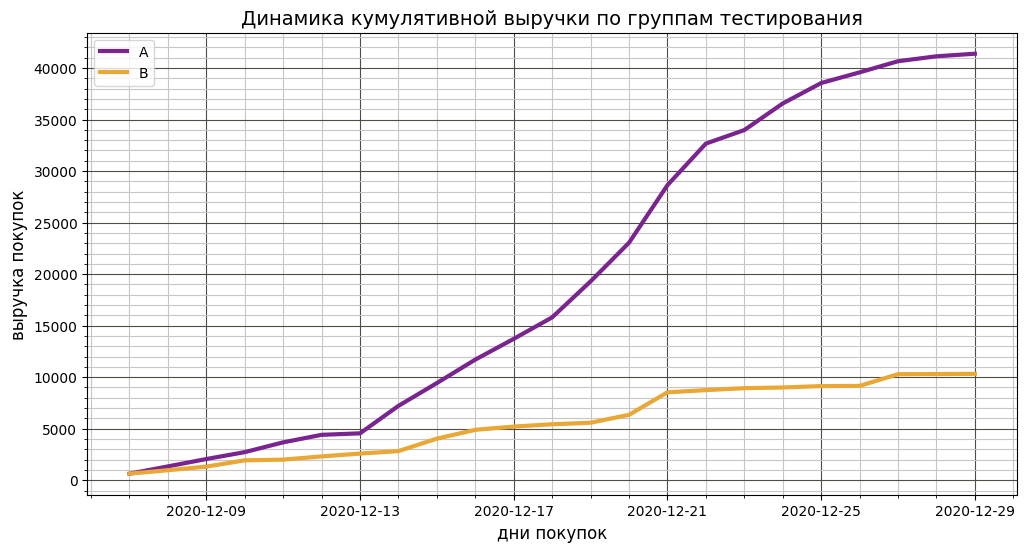

In [95]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группах А и B
cumulative_revenue_A = cumulative_data[cumulative_data['group']=='A'][['event_date','revenue', 'transactions']]
cumulative_revenue_B = cumulative_data[cumulative_data['group']=='B'][['event_date','revenue', 'transactions']]

# строим графики выручки группы А и B
plt.figure(figsize=(12,6))
plt.plot(cumulative_revenue_A['event_date'], cumulative_revenue_A['revenue'], label='A', linewidth=3, color='#79248f')
plt.plot(cumulative_revenue_B['event_date'], cumulative_revenue_B['revenue'], label='B', linewidth=3, color='#e9a735')
plt.title('Динамика кумулятивной выручки по группам тестирования', fontsize = 14)
ax = plt.gca()
ax.minorticks_on()
ax.grid(which='major', color='#4e4e47') # вертикальные линии для основных подписей на оси x
ax.grid(which='minor', color='#c6c6c6') # вертикальные линии для промежуточных дат
ax.set_xlabel('дни покупок', fontsize = 12)
ax.set_ylabel('выручка покупок', fontsize = 12)
plt.legend()
plt.show();

**Вывод:** кумулятивная выручка контрольной группы А растёт интенсивно с 13 декабря 2020 года, достигая своих максимальных значений в конце тестового периода 29 декабря 2020 года. Из положительных моментов экспериментальной группы мы можем отметить незначительный, но уверенный рост кумулятивной выручки в период с 15 по 21 декабря 2020 года. В целом, кумулятивная выручка группы B растёт существенно медленнее и показывает в финале результаты в 3.5 раза хуже контрольной группы.

<a id=5.2></a>
#### 5.2. График кумулятивного среднего чека по группам

В целях построения графика среднего чека по группам необходимо разделить кумулятивную выручку на кумулятивное число заказов.

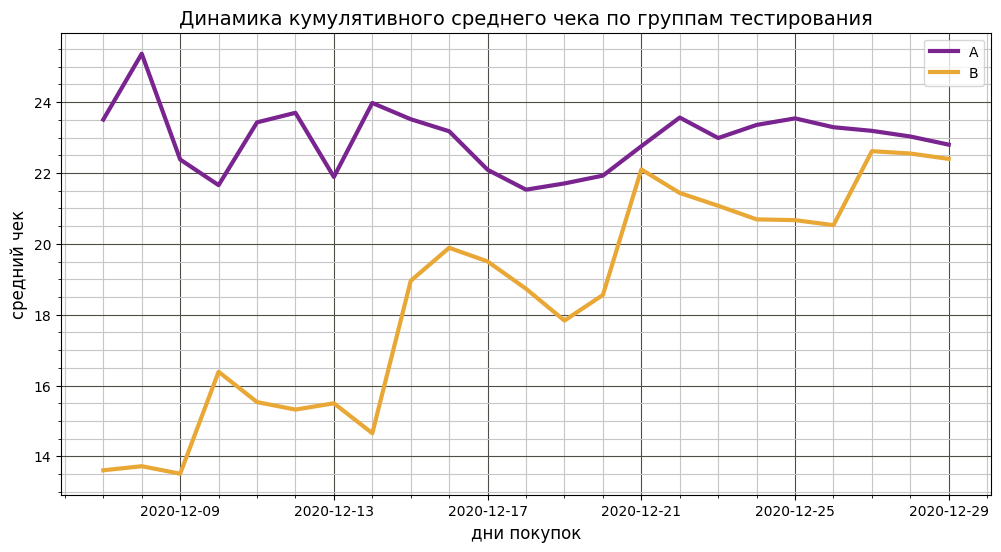

In [96]:
# строим график кумулятивного среднего чека групп А и B
plt.figure(figsize=(12,6))
plt.plot(cumulative_revenue_A['event_date'], cumulative_revenue_A['revenue'] / cumulative_revenue_A['transactions'], label='A', 
         linewidth=3, color='#79248f')
plt.plot(cumulative_revenue_B['event_date'], cumulative_revenue_B['revenue'] / cumulative_revenue_B['transactions'], label='B', 
         linewidth=3, color='#e9a735')
plt.title('Динамика кумулятивного среднего чека по группам тестирования', fontsize = 14)
ax = plt.gca()
ax.minorticks_on()
ax.grid(which='major', color='#4e4e47') # вертикальные линии для основных подписей на оси x
ax.grid(which='minor', color='#c6c6c6') #вертикальные линии для промежуточных дат
ax.set_xlabel('дни покупок', fontsize = 12)
ax.set_ylabel('средний чек', fontsize = 12)
plt.legend()
plt.show();

**Выводы:** величина среднего чека по группам колеблется со значительной амплитудой в первой половине периода проведения теста и стабилизируется с 16 декабря 2020 года.

До этой даты мы можем отметить существенный всплеск значений среднего чека в диапазоне от 25 до 29 денежных единиц в период с 8 по 12 декабря. Затем средний чек в контрольной группе к 18 декабря 2020 года снижается до отметки в 23 денежные единицы и стабилизируется на этом уровне до окончания тестового периода.

Динамика роста среднего чека экспериментальной группы B практически на всём периоде тестирования происходит рывками: до 13 декабря 2020 года - рост с 14 до 16 денежных единиц, затем плато значений до 13 декабря, а следом - снова очень резкий рост показателя до отметки в 21 денежную единицу, очередной пик роста до 23 денежных единиц отмечается 21 декабря - и это максимальная отметка для экспериментальной группы. До завершения теста средний чек здесь будет держаться на отметке 21 - 22 денежных единиц.

Полагаем самой наиболее вероятной причиной такого резкого роста среднего чека в экспериментальной группе влияние рождественского сейла в Европе.

<a id=5.3></a>
#### 5.3.  График относительного изменения кумулятивного среднего чека группы B к группе A

В целях построения графика относительного различия для среднего чека добавим горизонтальную ось методом `axhline()` (от англ. horizontal line across the axis, «горизонтальная линия поперек оси»):

In [97]:
# собираем данные в одном датафрейме
avg_rev_diff = cumulative_revenue_A.merge(cumulative_revenue_B, 
                                          left_on='event_date', right_on='event_date', how='left', suffixes=['_A', '_B'])

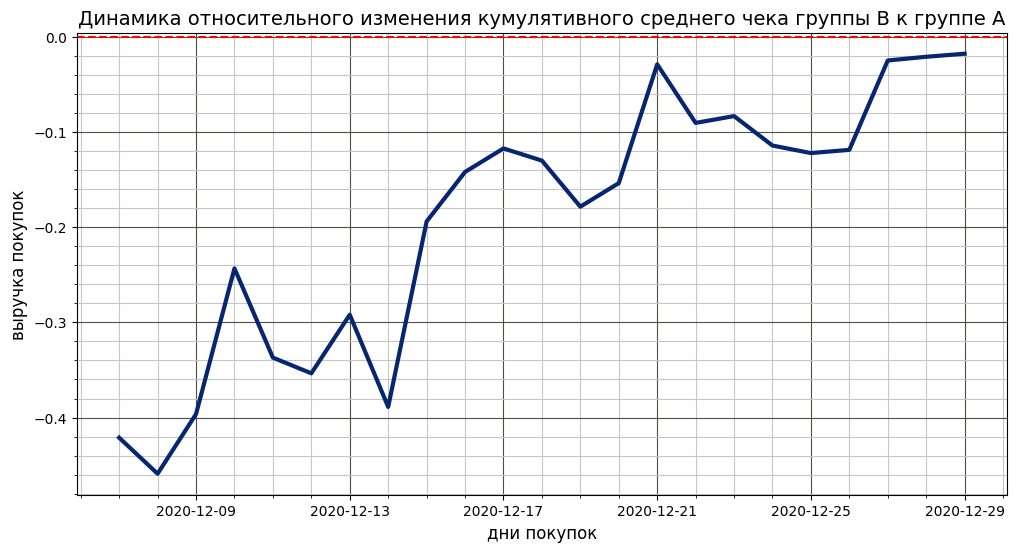

In [98]:
# cтроим отношение средних чеков
plt.figure(figsize=(12,6))
plt.plot(avg_rev_diff['event_date'], 
         (avg_rev_diff['revenue_B']/avg_rev_diff['transactions_B'])/(avg_rev_diff['revenue_A']/avg_rev_diff['transactions_A'])-1, \
        linewidth=3, color='#06266F')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Динамика относительного изменения кумулятивного среднего чека группы B к группе A', fontsize = 14)
ax = plt.gca()
ax.minorticks_on()
ax.grid(which='major', color='#4e4e47') # вертикальные линии для основных подписей на оси x
ax.grid(which='minor', color='#c6c6c6') #вертикальные линии для промежуточных дат
ax.set_xlabel('дни покупок', fontsize = 12)
ax.set_ylabel('выручка покупок', fontsize = 12)
plt.show();

**Вывод:** относительное изменение среднего чека экспериментальной группы на всём периоде проведения тестирования демонстрирует отрицательную динамику, с 14 декабря 2020 года происходит скачок в росте разницы с последующей стабилизацией на отметке от -0,1 до -0,05 вплоть до окончания периода тестирования, однако, это малоутешительные результаты. Пиковый рост был спровоцирован, предположительно, всеобщим ажиотажем рождественских сейлов и как таковой не показывает качественного развития использования улучшенной рекомендательной системы в группе B.

<a id=5.4></a>
#### 5.4. График кумулятивного среднего количества заказов на посетителя по группам

In [99]:
# отделяем данные по группам A и B
cumulative_data_A = cumulative_data[cumulative_data['group']=='A']
cumulative_data_B = cumulative_data[cumulative_data['group']=='B']

In [100]:
# среднее и медианное значение конверсии в контрольной группе A
print(cumulative_data_A['conversion'].mean())
print(cumulative_data_A['conversion'].median())

0.1280027762301718
0.12753036437246965


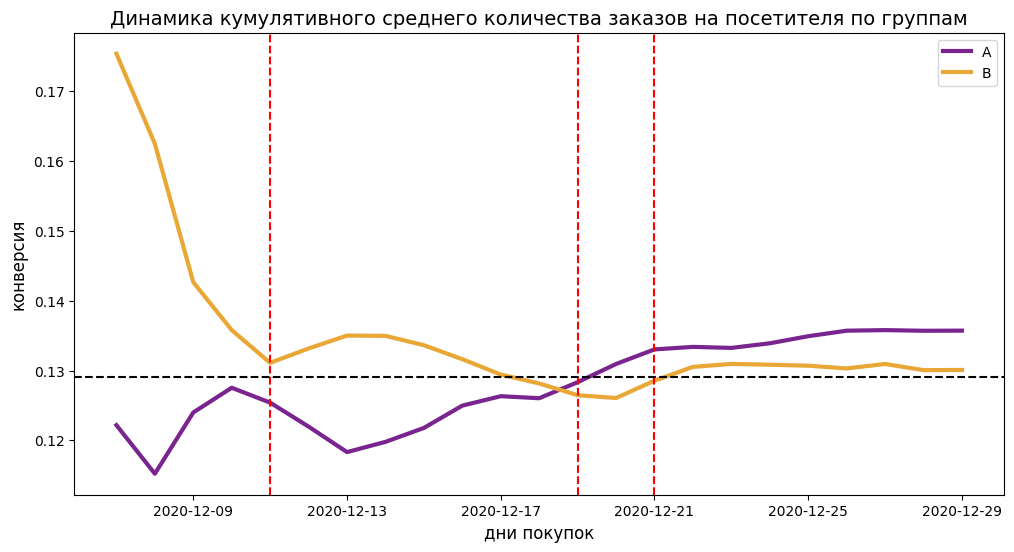

In [101]:
# считаем кумулятивную конверсию
cumulative_data['conversion'] = cumulative_data['transactions'] / cumulative_data['visitors']

# строим графики
plt.figure(figsize=(12,6))
plt.plot(cumulative_data_A['event_date'], cumulative_data_A['conversion'], label='A', linewidth=3, color='#79248f')
plt.plot(cumulative_data_B['event_date'], cumulative_data_B['conversion'], label='B', linewidth=3, color='#e9a735')

# линии переломного момента роста конверсии по группам
plt.axvline(x=cumulative_data_A['event_date'][8], color='red', linestyle='--') # рубеж 11 декабря 2020 года, пересечение
plt.axvline(x=cumulative_data_A['event_date'][24], color='red', linestyle='--') # рубеж 19 декабря 2020 года, 
plt.axvline(x=cumulative_data_A['event_date'][28], color='red', linestyle='--') # рубеж 21 декабря 2020 года, стабилилзация
plt.axhline(y=0.129, color='black', linestyle='--') # линия конверсии в 0.129
plt.title('Динамика кумулятивного среднего количества заказов на посетителя по группам', fontsize = 14)
plt.xlabel('дни покупок', fontsize = 12)
plt.ylabel('конверсия', fontsize = 12)
plt.legend()
plt.show();

**Вывод:** после резких колебаний до 11 декабря 2020 года среднее количество заказов на пользователя в разрезе принадлежности к той или иной группе теста, не показывает радикальных отличий. Да, в общем и целом, среднее количество заказов в контрольной группе растёт с 13 декабря и стабилизируется после 20 декабря, что выглядит естественным и закономерным.

Среднее количество заказов в экспериментальной группе начинает свою историю существования с феноменального провала: будучи впервые зафиксированным на отметке существенно выше, чем конверсия контрольной группы, значение стремительно падает вниз за каких-то пару дней и сравнивается с контрольной группой. В иных условиях проведения A/B-тестирования эти несколько дней могли бы дать хорошубю пищу для размышлений сотрудникам отдела маркетинга, ведь именно здесь промелькнула и погасла надежда на успешное внедрение новой рекомендательной системы. После падения среднее количество заказов в экспериментальной группе приближается к отметке средней конверсии контрольной группы в период с 19 декабря, а стабилизитруется также после 21 декабря 2020 года.

<a id=5.5></a>
#### 5.5. График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A

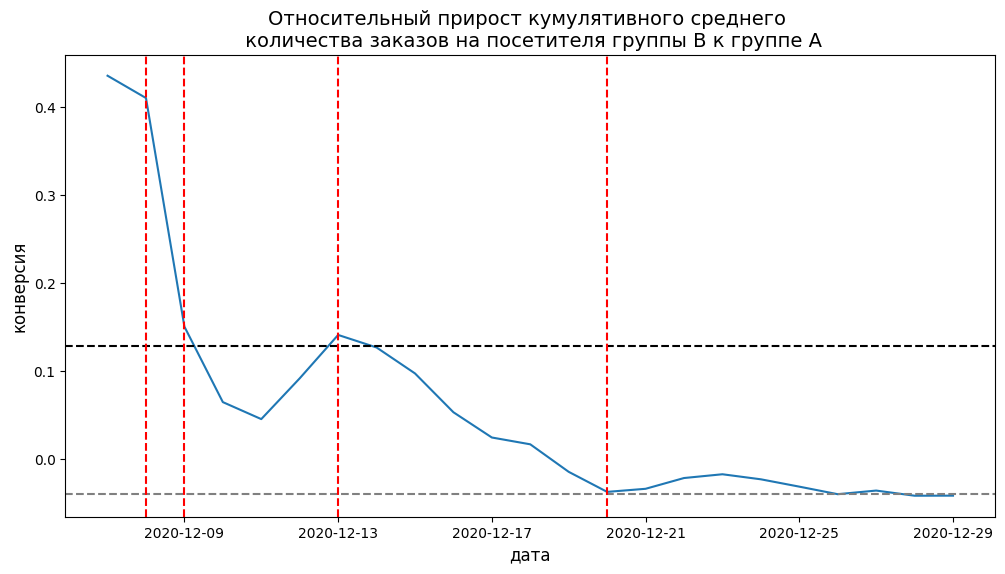

In [102]:
# объединяем таблицы с конверсиями по группам
merged_cumulative_conversions = cumulative_data_A[['event_date','conversion']].\
merge(cumulative_data_B[['event_date','conversion']], 
      left_on='event_date', right_on='event_date', how='left', suffixes=['_A', '_B'])

# строим график
plt.figure(figsize=(12,6))
plt.plot(merged_cumulative_conversions['event_date'], merged_cumulative_conversions['conversion_B']/merged_cumulative_conversions['conversion_A']-1)

plt.axhline(y=0.129, color='black', linestyle='--') # линия конверсии в контрольной группе, равная 0.129
plt.axhline(y=-0.04, color='grey', linestyle='--') # медианная относительная конверсия на отметке -0.04

# линия переломного момента роста конверсии по группам
plt.axvline(x=cumulative_data_A['event_date'][2], color='red', linestyle='--') # рубеж 8 декабря 2020 года, рост
plt.axvline(x=cumulative_data_A['event_date'][4], color='red', linestyle='--') # рубеж 9 декабря 2020 года, падение
plt.axvline(x=cumulative_data_A['event_date'][12], color='red', linestyle='--') # рубеж 13 декабря 2020 года, рост
plt.axvline(x=cumulative_data_A['event_date'][26], color='red', linestyle='--') # рубеж 16 декабря 2020 года, стабилизация

plt.title('Относительный прирост кумулятивного среднего \n количества заказов на посетителя группы B к группе A', fontsize = 14)
plt.ylabel('конверсия', fontsize=12)
plt.xlabel('дата', fontsize=12)
plt.show();

**Вывод:** на раннем этапе проведения A/B-теста группа В явно выигрывала у группы А, но затем решительно сдала позиции. Конверсия покупателей в группе B стремительно падала с 8 декабря 2020 года, кратковременный период роста (с 9 по 13 декабря 2020 года) закончился стабилизацией на уровне отрицательных значений. 

<a id=5.6></a>
#### 5.6. Диаграмма рассеяния количества заказов по пользователям

Количество заказов напрямую влияет на конверсию, поскольку находится в числителе этой расчётной формулы. В знаменателе - количество посетителей сайта за весь период проведения A/B-теста. Частота совершения покупок пользователем на сайте зависит от продаваемых товаров и услуг: одна-две покупки в месяц в большинстве случаев будут нормой (магазин онлайн-игр, книжный магазин, запчасти или детали для аппаратуры), чаще покупки совершаются в интернет-магазинах, предлагающих товары первой необходимости (продуктовые магазины, аптеки и т.п.). В целях рассмотрения количества заказов по пользователям, необходимо сгруппировать исходные данные датафрейма:

In [103]:
# группировка данных по уникальным пользователям
orders_by_users = df.groupby('user_id', as_index=False).agg({'event_dateNtime': 'nunique', 'group':'max'})

# присваиваем имена столбцам в получившемся сгруппированном датафрейме
orders_by_users.columns =  ['user_id', 'transactions', 'group']

In [104]:
# первичная описательная статистика по признаку 'transactions'
print(orders_by_users['transactions'].describe())
print('Среднее значение: ', orders_by_users['transactions'].mean())
print('Медианное значение: ', orders_by_users['transactions'].median())

count   2594.00
mean       4.37
std        2.23
min        1.00
25%        3.00
50%        4.00
75%        6.00
max       14.00
Name: transactions, dtype: float64
Среднее значение:  4.373554356206631
Медианное значение:  4.0


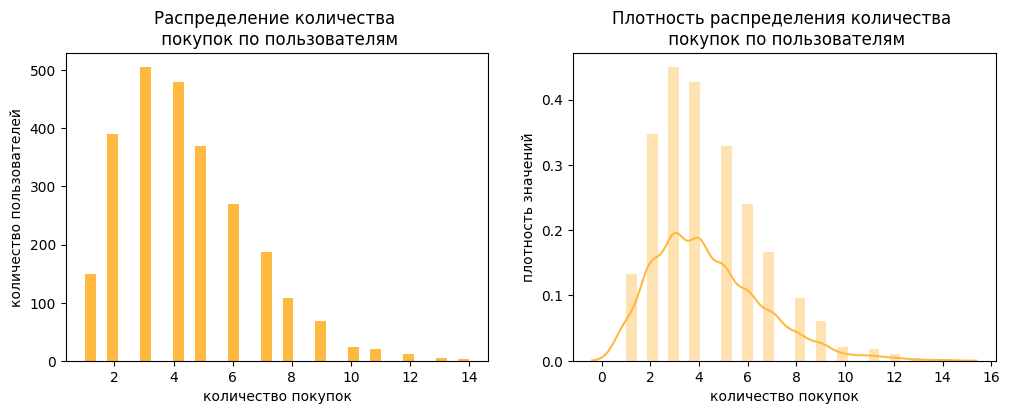

In [105]:
# парные диаграммы для признака 'transactions'
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title('Распределение количества \n покупок по пользователям')
orders_by_users['transactions'].hist(figsize=(12,4), grid=False, bins= 35, color='#FFB840').set(ylabel = 'количество пользователей', 
                                                                                                xlabel = 'количество покупок')

plt.subplot(1,2,2)
plt.title('Плотность распределения количества \n покупок по пользователям')
sns.distplot(orders_by_users['transactions'], color = '#FFB840').set(ylabel = 'плотность значений', 
                                                                     xlabel = 'количество покупок')

plt.show()

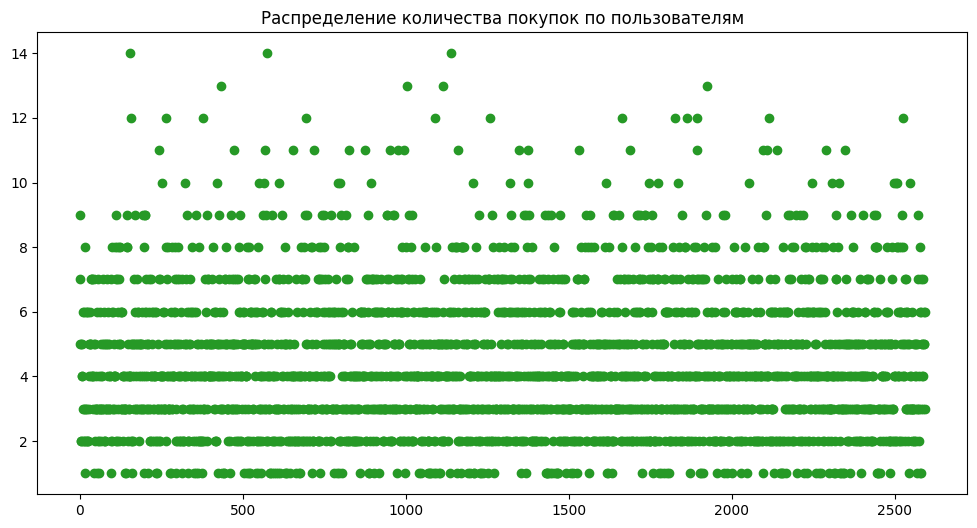

In [106]:
# точечная диаграмма для признака 'transactions', обощённые данные
x_values = pd.Series(range(0,len(orders_by_users)))
plt.figure(figsize=(12,6))
plt.scatter(x_values, orders_by_users['transactions'], color='#269926')
plt.title('Распределение количества покупок по пользователям')
plt.show();

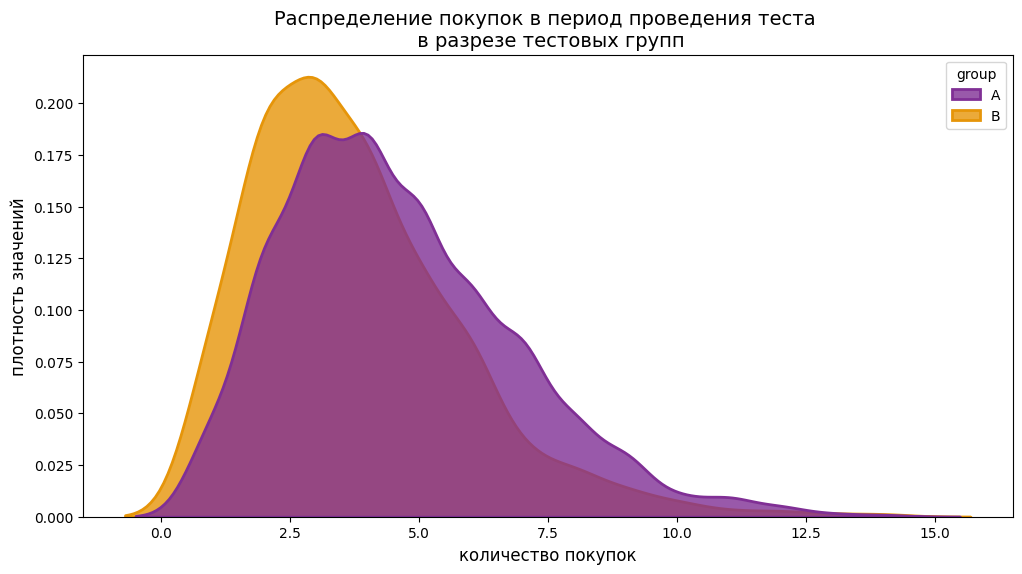

In [107]:
# плотность покупок на пользователей в группах теста
plt.figure(figsize=(12,6))
sns.kdeplot(data=orders_by_users, x='transactions', hue='group', common_norm=False, fill=True, 
            palette='CMRmap', alpha=0.8, linewidth=2)
plt.title('Распределение покупок в период проведения теста \n в разрезе тестовых групп', fontsize=14)
plt.ylabel('плотность значений', fontsize=12)
plt.xlabel('количество покупок', fontsize=12)
plt.show();

**Выводы:** полученные результаты описательной статистики и визуализация графиков типа `hist`, `distplot`, `scatter` и `kde` позволяют нам сделать однозначный вывод о численном превосходстве посетителей сайта, которые за период проведения A/B-теста совершили 3-4 заказа, таких пользователей насчитывается 985 человек. Также широко представлены пользователи, совершившие 5-6 покупок, их насчитывается 640 человек.

<a id=5.7></a>
#### 5.7. Расчёт 95-го и 99-го перцентили количества заказов на пользователя

In [108]:
# перцентили количества заказов на одного пользователя
np.percentile(orders_by_users['transactions'], [95, 99])

array([ 9., 11.])

In [109]:
# перцентили количества заказов на одного пользователя
np.percentile(orders_by_users.query('group=="A"')['transactions'], [95, 99])

array([ 9., 11.])

In [110]:
# перцентили количества заказов на одного пользователя
np.percentile(orders_by_users.query('group=="B"')['transactions'], [95, 99])

array([ 8., 10.])

**Вывод:** значения на обобщённых данных совпадают со значениями контрольной группы. Абсолютное большинство пользователей в контрольной группе совершили до 8 заказов на пользователя, в экспериментальной группе этот показатель находится на такой же отметке.

<a id=5.8></a>
#### 5.8. Диаграмма рассеяния стоимостей заказов

In [111]:
# первичная описательная статистика по признаку `details` ('revenue')
print(df['details'].describe())
print('Среднее значение: ', df['details'].mean())
print('Медианное значение: ', df['details'].median())

count   2277.00
mean      22.71
std       68.51
min        4.99
25%        4.99
50%        4.99
75%        9.99
max      499.99
Name: details, dtype: float64
Среднее значение:  22.70848924022837
Медианное значение:  4.99


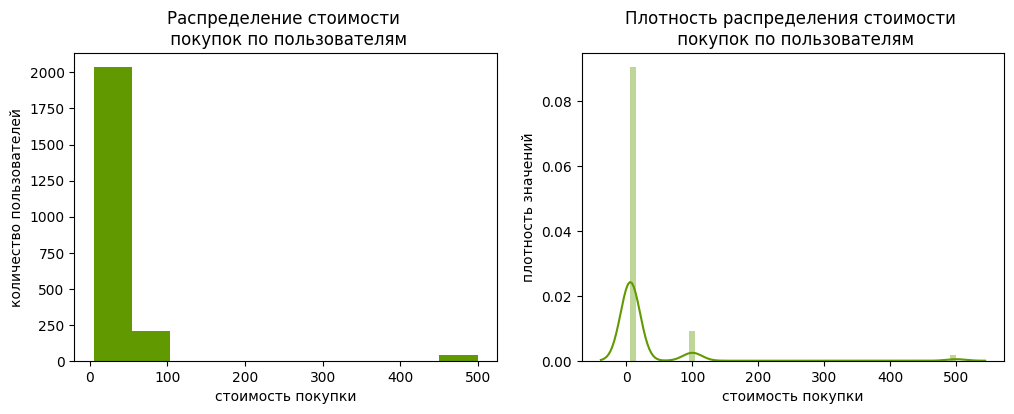

In [112]:
# парные диаграммы для признака `details` ('revenue')
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title('Распределение стоимости \n покупок по пользователям')
df['details'].hist(figsize=(12,4), grid=False, color='#619A00').set(ylabel = 'количество пользователей', xlabel = 'стоимость покупки')

plt.subplot(1,2,2)
plt.title('Плотность распределения стоимости \n покупок по пользователям')
sns.distplot(df['details'], color = '#619A00').set(ylabel = 'плотность значений', xlabel = 'стоимость покупки')

plt.show()

<Figure size 1200x600 with 0 Axes>

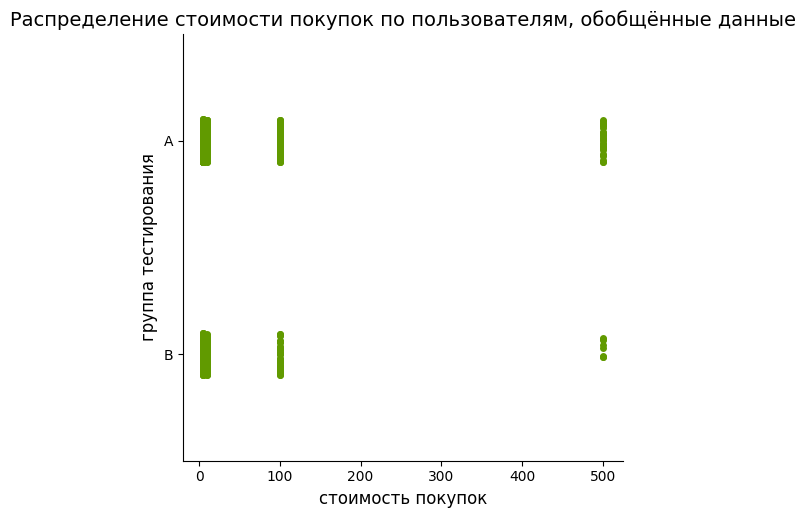

In [113]:
# точечная диаграмма для признака `details` ('revenue')
plt.figure(figsize=(12,6))
x_values = pd.Series(range(0,len(df['details'])))
sns.catplot(data=df, y='group', x='details', color='#619A00')
plt.title('Распределение стоимости покупок по пользователям, обобщённые данные', fontsize=14)
plt.xlabel('cтоимость покупок', fontsize=12)
plt.ylabel('группа тестирования', fontsize=12)
plt.show();

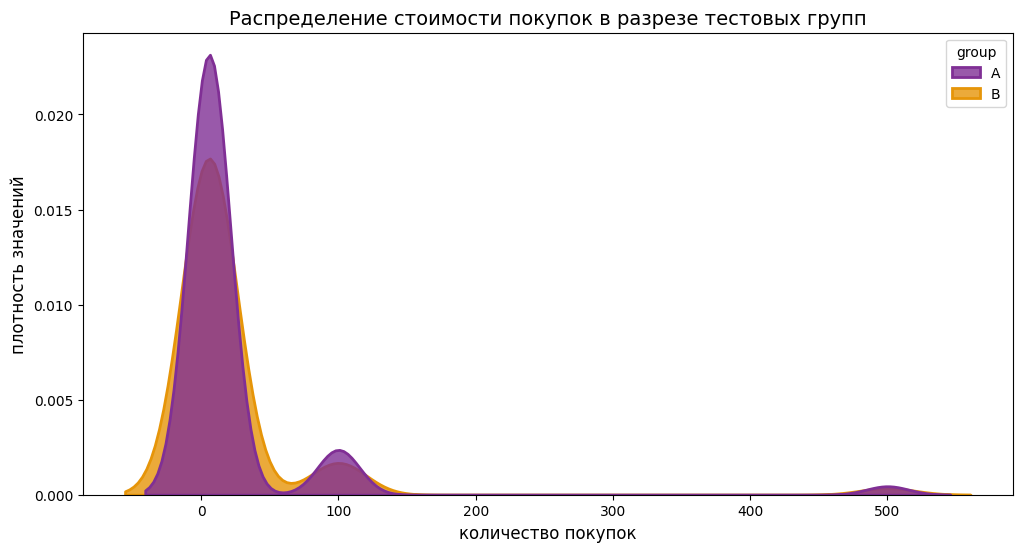

In [114]:
# плотность стоимости покупок на пользователя в группах теста
plt.figure(figsize=(12,6))
sns.kdeplot(data=df, x='details', hue='group', common_norm=False, fill=True, 
            palette='CMRmap', alpha=0.8, linewidth=2)
plt.title('Распределение стоимости покупок в разрезе тестовых групп', fontsize=14)
plt.ylabel('плотность значений', fontsize=12)
plt.xlabel('количество покупок', fontsize=12)
plt.show();

**Вывод:** отсутствие существенной разницы между средним и медианным значением свидетельствует об однородности данных и незначительном присутствии аномальных значений по признаку `revenue` в обеих группах. Этот тезис подтверждается графиками визуализации признака как на обобщённых данных, так и в разрезе по группам A и B. Абсолютное большинство (95% пользователей) совершили покупки на сумму до 100 денежных единиц.

<a id=5.9></a>
#### 5.9. Расчёт 95-го и 99-го перцентиля стоимости заказов

In [115]:
# перцентили стоимости заказов на одного пользователя
np.percentile(df[~df['details'].isna()]['details'], [95, 99])

array([ 99.99, 499.99])

In [116]:
# перцентили стоимости заказов на одного пользователя, контрольная группа
np.percentile(df.query('group=="A"')[~df['details'].isna()]['details'], [95, 99])

array([ 99.99, 499.99])

In [117]:
# перцентили стоимости заказов на одного пользователя, экспериментальная группа
np.percentile(df.query('group=="B"')[~df['details'].isna()]['details'], [95, 99])

array([ 99.99, 499.99])

**Вывод:** значения на обобщённых данных совпадают со значениями тестовых групп. Абсолютное большинство пользователей в обеих группах совершили покупки стоимостью до 100 денежных единиц, данные по этому признаку — однородные.

<a id=5.10></a>
#### 5.10. Расчёт статистической значимости различий в среднем количестве заказов на посетителя между группами

Рассчитаем статистическую значимость различий в среднем числе заказов на пользователя и среднем чеке между группами.

Сформулируем гипотезы:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : конверсия в группе A} = \text{конверсия в группе B}
   \\
   \text{H}_1 \text{ : конверсия в группе A} \neq \text{конверсия в группе B}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.05$

Для дальнейшей работы необходимо подготовить соответствующий датафрейм. Практика показывает, что данные о продажах и средних чеках редко бывают нормально распределены и это весьма распространённый пример переменных, подверженных выбросам. Следовательно, для проверки гипотез нами будет использован непараметрический `тест Уилкоксона-Манна-Уитни`. В качестве порогового значения мы установим стандартный уровень статистической значимости, равный `0.05`.

Подготовим данные для A/В-тестирования. Выберем в датасете событие `purchase`, сгруппируем его по пользователям и группе A/B-теста, посчитаем количество событий. Сохраним результат в переменную `purchase`.

In [118]:
# группировка данных по типу события - покупке, пользователям и группе теста
purchase = df[df['event_name'] == 'purchase'].groupby(['user_id', 'group'], as_index=False).agg({'event_name' : 'count'})
purchase.head()

,user_id,group,event_name
0,0010A1C096941592,A,4
1,005E096DBD379BCF,B,2
2,00C1F5175586DFCF,A,3
3,01157AAD4401952B,A,3
4,0145A5A1EC388D99,A,2


In [119]:
# покупки контрольной группы и экспериментальной группы
purchase_A = purchase.query('group == "A"')
purchase_B = purchase.query('group == "B"')

In [120]:
# расчёт общего количества событий для контрольной и экспериментальной групп
print('Количество событий в котрольной группе:', df.query('group == "A"')['event_name'].count())
print('Количество событий в экспериментальной группе:', df.query('group == "B"')['event_name'].count())

Количество событий в котрольной группе: 13374
Количество событий в экспериментальной группе: 3544


Для подготовки выборок к проверке критерием Манна-Уитни объявим переменные `sample_A` и `sample_B`, в которых пользователям из разных групп будет соответствовать количество заказов. Тем, кто ничего не заказал, будут соответствовать нули. Переменная `sample` является разностью двух значений:

1. количество всех типов событий в соответствующей группе или нули для пользователей, которые не совершали событий
2. количество событий типа "покупка" в соответствующей группе.

Создадим список индексов функцией `np.arange()`, создающей массив индексов в формате `np.array`, который требуется для `pd.Series`. Объединим последовательности функцией `pd.concat()` с добавлением параметра `axis=0` — по строкам.

In [121]:
# выборка по контрольной группе
sample_A = pd.concat(
    [purchase_A['event_name'],pd.Series(0, index=np.arange(df.query('group == "A"')['event_name'].count() - \
        len(purchase_A['event_name'])), name='event_name')], axis=0)

In [122]:
# выборка по экспериментальной группе
sample_B = pd.concat(
    [purchase_B['event_name'],pd.Series(0, index=np.arange(df.query('group == "B"')['event_name'].count() - \
        len(purchase_A['event_name'])), name='event_name')], axis=0)

In [123]:
# проводим непараметрический тест Уилкоксона-Манна-Уитни

# альфа-уровень статистической значимости
alpha = 0.05

# статистический тест
results = st.mannwhitneyu(sample_A, sample_B)

print('p-значение: ', "{0:.3f}".format(results.pvalue))

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу: разница статистически значима.')
else:
    print('Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя.')

p-значение:  0.001
Отвергаем нулевую гипотезу: разница статистически значима.


**Вывод:** непараметрический статистический тест Манна-Уитни позволил нам отвергнуть нулевую гипотезу, между конверсией в контрольной группе A и конверсией в экспериментальной группе B существует статистически значимая разница.

<a id=5.11></a>
#### 5.11. Расчёт статистической значимости различий в доле пользователей контрольной и экспериментальной группы на каждом шаге воронки событий

Визуальное знакомство с полученными данными позволяет нам сделать первичное предположение о том, что нововведение в форме улучшенной рекомендательной системы не возымело положительного воздействия на пользователей.

В нашем распоряжении не только агрегированные данные и дополнительные построения диаграммы воронки событий в разрезе каждой тестовой группы, но и статистические методы. Для проверки равенства средних значений генеральной совокупности, когда дисперсии известны и размер выборки велик, обычно применяется `z-критерий Фишера`, основанный на нормальном распределении данных. 

Напишем цикл проверки статистических критерией разницы между долями по шагам воронки событий в контрольной и экспериментальной группах. Цикл проведёт вычисления на приниципиально важных для нас этапах воронки, где мы ожидаем рост метрик. Наименования этих событий передадим в отдельный список. 

Сформулируем универсальный макет гипотез:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : доля пользователей группы A на текущем шаге воронки событий} = \text{доля пользователей группы B на текущем шаге воронки событий}
   \\
   \text{H}_1 \text{ : доля пользователей группы A на текущем шаге воронки событий} \neq \text{доля пользователей группы B на текущем шаге воронки событий}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.05$

In [124]:
# ещё раз сформируем переменную `events` и дополним её расчётом процентов
events = df.pivot_table(index='group', columns='event_name', values='user_id', aggfunc='nunique')
events['registration'] = ''
events.loc[events.index == 'A', 'registration'] = df[df.group == "A"]['user_id'].nunique()
events.loc[events.index == 'B', 'registration'] = df[df.group == "B"]['user_id'].nunique()
events = events[['registration', 'login', 'product_page', 'product_cart', 'purchase']]
events = events.T

In [125]:
# дополним созданную ранее переменную по событиям в группах тестирования
events['A_previous'] = events['A'] / events['A'].shift()
events['A_previous'] = events['A_previous'].fillna(1)
events['A_previous'] = events['A_previous'].apply(lambda x: "{0:.1f}%".format(x * 100))

events['B_previous'] = events['B'] / events['B'].shift()
events['B_previous'] = events['B_previous'].fillna(1)
events['B_previous'] = events['B_previous'].apply(lambda x: "{0:.1f}%".format(x * 100))

events['A_initial'] = events['A'] / events.loc['registration', 'A']
events['A_initial'] = events['A_initial'].apply(lambda x: "{0:.1f}%".format(x * 100))

events['B_initial'] = events['B'] / events.loc['registration', 'B']
events['B_initial'] = events['B_initial'].apply(lambda x: "{0:.1f}%".format(x * 100))
events

group,A,B,A_previous,B_previous,A_initial,B_initial
event_name,,,,,,
registration,1939,655,100.0%,100.0%,100.0%,100.0%
login,1939,654,100.0%,99.8%,100.0%,99.8%
product_page,1265,367,65.2%,56.1%,65.2%,56.0%
product_cart,589,184,46.6%,50.1%,30.4%,28.1%
purchase,613,191,104.1%,103.8%,31.6%,29.2%


In [126]:
# альфа-уровень статистической значимости
alpha = 0.05

# список событий, по которым мы ожидаем увеличение метрик
event_name = ['product_page', 'product_cart', 'purchase']

for i in event_name:
    # подсчёт количества событий в каждой группе
    successes = np.array([events.loc[i, 'A'], events.loc[i, 'B']])

    # всего
    trials = np.array([events.loc['login', 'A'], events.loc['login', 'B']])

    # пропорция успехов в первой группе:
    p1 = successes[0]/trials[0]

    # пропорция успехов во второй группе:
    p2 = successes[1]/trials[1]
    
    print(trials[0], trials[1])

    # пропорция успехов в комбинированном датасете:
    p_combined = (successes[0] + successes[1]) / (trials[0] + trials[1])

    # разница долей в датафреймах групп
    difference = p1 - p2

     # считаем статистику в стандартных отклонениях стандартного нормального распределения
    z_value = difference / math.sqrt(p_combined * (1 - p_combined) * (1/trials[0] + 1/trials[1]))

    # задаем стандартное нормальное распределение (среднее 0, тандартное отклонение 1)
    distr = st.norm(0, 1)

    # поскольку это двусторонний тест, удваиваем результат
    p_value = (1 - distr.cdf(abs(z_value))) * 2

    print('p-значение: ', "{0:.7f}".format(p_value))

    # поправка Бонферрони
    bnf_alpha = alpha / 3
    
    if (p_value < bnf_alpha):
        print("Отвергаем нулевую гипотезу: между группами A и B по событию", i, "есть значимая разница.")
    else:
        print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли выборок A и B по событию", i, "разными.")

1939 654
p-значение:  0.0000295
Отвергаем нулевую гипотезу: между группами A и B по событию product_page есть значимая разница.
1939 654
p-значение:  0.2784250
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли выборок A и B по событию product_cart разными.
1939 654
p-значение:  0.2493302
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли выборок A и B по событию purchase разными.


**Вывод:** нет статистически значимой разницы между конверсиями групп A и B в покупку и в переход на страницу оплаты картой. Между конверсиями в переход на страницу продукта есть значимая разница, при этом конверсия группы B на 16% ниже.

<a id=5.12></a>
#### 5.12. Принятое решение по результатам A/B-теста и его аргументация

Создадим вспомогательные данные для визуального подкрепления полученных ранее результатов и обоснования принятого решения.

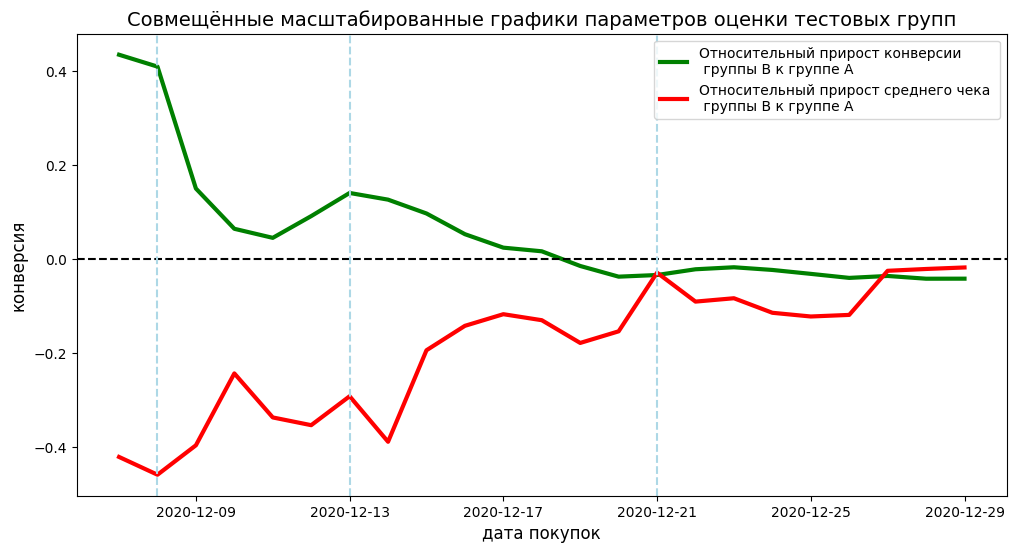

In [127]:
# график различия среднего количества заказов в разрезе групп
plt.figure(figsize=(12,6))

x1 = merged_cumulative_conversions['event_date']
y1 = merged_cumulative_conversions['conversion_B']/merged_cumulative_conversions['conversion_A']-1
x2 = merged_cumulative_conversions['event_date']
y2 = (avg_rev_diff['revenue_B']/avg_rev_diff['transactions_B'])/(avg_rev_diff['revenue_A']/avg_rev_diff['transactions_A'])-1

plt.plot(x1, y1, 'g-', linewidth=3, label='Относительный прирост конверсии \n группы B к группе A')
plt.plot(x2, y2, 'r-', linewidth=3, label='Относительный прирост среднего чека \n группы B к группе A')

plt.axhline(y=0, color='black', linestyle='--') # нулевой уровень конверсии
plt.axvline(x=avg_rev_diff['event_date'][1], color='lightblue', linestyle='--') # рубеж 8 декабря 2020 года, рост чека
plt.axvline(x=avg_rev_diff['event_date'][6], color='lightblue', linestyle='--') # рубеж 13 декабря 2020 года, падение конверсии и рост чека
plt.axvline(x=avg_rev_diff['event_date'][14], color='lightblue', linestyle='--') # рубеж 21 декабря 2020 года, стабилизация конверсии и чека

plt.title('Совмещённые масштабированные графики параметров оценки тестовых групп', fontsize=14)
plt.ylabel('конверсия', fontsize=12)
plt.xlabel('дата покупок', fontsize=12)
plt.legend(fontsize=10)
plt.show();

Установленные факты:
* нет статистически значимой разницы между конверсиями групп A и B в переход на страницу оплаты картой;
* есть статистически значимая разница между конверсиями групп A и B в покупку;
* между конверсиями в переход на страницу продукта есть статистически значимая разница, при этом конверсия группы B на 16% ниже;
* график различия среднего чека говорит о том, что результаты экспериментальной группы B существенно хуже результата контрольной группы.

Сушествуют следующие врианты решения по результатам теста:
<br>1. Остановить тест, зафиксировать победу одной из групп.
<br>2. Остановить тест, зафиксировать отсутствие различий между группами.
<br>3. Продолжить тест.

Исходя из выявленных фактов, полагаем необходимым **тест признать неуспешным, зафиксировать победу группы A.** При имеющихся данных:
1. Кумулятивная выручка по группе A значительно выше, чем по группе B.
2. Показатель конверсии пользователей в группе A существенно выше аналогичного показателя в группе B.
3. Средний чек пользователей в группе B находился в стадии активного роста очень короткий период c до 16 декабря 2020 года, однако, затем происходит стабилизация и показатель так и не добирается до уровня группы A.

<a id=6></a>
### Шаг 6. Выводы

На заре развития всемирной сети Интернет едва ли кто-то мог предположить, что online-покупки станут настолько популярным и общепринятым способом торговли. Даже когда торговля уже сделала решительный шаг в цифровую реальность, многие пользователи с недоверием и опаской относились к идее удалённого шоппинга. С лавинообразным развитием цифровых технологий, популярность виртуальных торговых площадок стала неоспоримым фактом, а сами online-покупки - неотъемлемой частью жизни многих людей.

Высокая популярность и повсеместное  признание  пользователей  являются следствием характерных  черт  организационных  принципов работы интернет-магазинов:

* большой ассортимент без сезонных ограничений;
* выгодные цены по сравнению с офлайн рынком, продукция в онлайн стоит дешевле (владелец виртуальной точки не платит за аренду торгового зала и коммунальных услуг, не нанимает десяток продавцов-консультантов);
* быстрая навигация в ассортименте (фильтрация потребительских характеристик помогает быстро отобрать необходимые по качеству и количеству товары);
* круглосуточная доступность (интернет-магазины открыты в режиме 24/7, работают в выходные и праздники);
* быстрое информирование пользователя об новинках, акциях, скидках.

Рынок следует за потребителем: традиционные офлайн розничные магазины открывают интернет-магазины, организовывают доставку на дом, общаются с покупателями вне точек продаж через социальные сети и мессенджеры. Одновременно с этим, безусловно, при всех достоинствах и сильных сторонах, интернет-торговля обладает и слабыми сторонами:

* нестабильной работы сайта;
* сложной организации логистики;
* перенасыщенности рынка;
* высокого риска мошенничества;
* времени на создание и запуск сайта интернет-магазина.

Данное проектное исследование посвящено анализу деятельности уже существующего сайта интернет-магазина. В роли аналитика данных, нам предстояло получить данные для А/В-теста и проанализировать полученные результаты. В соответствии с этими задачами, в работу поступило 4 датафрейма, содержащие ту или иную информацию для исследования: данные о самих маркетинговых событиях - акциях, лотереях, рекламных кампаниях в период с 25 января 2020 года по 1 июля 2021 года; данные о пользователях, зарегистрировавшихся в интернет-магазине в период с 7 по 21 декабря 2020 года; данные о событиях новых пользователей в период с 7 декабря 2020 по 4 января 2021 года и, собственно, таблица с обезличенными данными участников A/B-тестирования.

Нами был импортирован ряд библиотек, в том числе `pandas` для работы с массивами данных, `plotly`, `matplotlib` и `seaborn` для визуализации полученных результатов, а также модуль `stats` библиотеки `scipy` для корректной работы со статистическими гипотезами.

Осуществлена загрузка исходных данных методом `read_csv`. В работу поступили 4 датафрейма, содержащие ту или иную информацию для исследования: данные о самих маркетинговых событиях - акциях, лотереях, рекламных кампаниях в период с 25 января 2020 года по 1 июля 2021 года (14 строк на 4 столбца); данные о пользователях, зарегистрировавшихся в интернет-магазине в период с 7 по 21 декабря 2020 года (61733 строк на 4 столбца); данные о событиях новых пользователей в период с 7 декабря 2020 по 4 января 2021 года (440317 строк на 4 столбца и, собственно, таблица с обезличенными данными участников A/B-тестирования (18268 строк на 3 столбца).

На основании результатов последовательного применения методов `min()`, `max()`, `unique()`, `info()` и `describe()` мы получили первичную информацию для статистического анализа. Исходные датафреймы разноразмерны. При первичном исследовании данных выявлено несоответствие типов хранимой информации, а также наличие пропусков. Изучим более подробно массивы данных в следующем исследовательском разделе проекта.

Обязательным этапом была выполнена предварительная обработка данных. В процессе формирования обобщённой информации нами выполнено преобразование типов данных: `marketing_calendar['start_dt']`, `marketing_calendar['finish_dt']`, `users_regions['first_date']`, `users_events['event_dt']`. Выявлено 85.75% пропусков значений в признаке `users_events['details']`. По итогам группировки данных установлено, что признак `details` описывает стоимостные категории товаров на сайте. Во всех 4 датафреймах установлено отсутствие полных дубликатов, неполные дубликаты выявлены в 3 датафреймах по сочетанию уникального номера пользователя и группы тестирования, следовательно, мы имеем дело с пересечением тестовых групп пользователей.

Подготовка данных в соответствии с техническим заданием методом `intersection()` и последовательной фильтрации данных по условиям приводят нас к выводу не только о несоблюдении требований технического задания, но и глобально о некорректной организации проведения тестирования. Обобщённые итоги проверки имеющихся данных на соответствие техническому заданию представлены в таблице ниже:

|№ п/п|Наименование условия технического задания|выполняется|не выполняется|
|-----|:----------------------------------------|-----------|--------------|
|1.|Наличие двух групп тестирования: А (контрольная), B (новая платёжная воронка)|+||
|2.|Дата запуска: 2020-12-07|+||
|3.|Дата остановки набора новых пользователей: 2020-12-21|+||
|4.|Дата остановки: 2021-01-04||+|
|5.|Аудитория: 15% новых пользователей из региона EU||+|
|6.|Ожидаемое количество участников теста: 6000||+|
|7.|Ожидаемый эффект: за 14 дней с момента регистрации в системе <br>пользователи покажут улучшение каждой метрики не менее, чем на 10%, а именно: <br>конверсии в просмотр карточек товаров — событие `product_page`, <br>просмотры корзины — `product_cart`, <br>покупки — `purchase`||+|

Время проведения теста совпадает с `Christmas&New Year Promo`, стартующим 25 декабря 2020 года. И это ещё один существенный минус дизайна проведения текущего A/B-тестирования: изменения поведения пользователей, спровоцированные распродажей или очень выгодной акцией, не могут стать надёжным ориентиром для разработки дальнейшей стратегии. Также, имеются 1602 случая пересечений с конкурирующим тестом `interface_eu_test`. После их удаления количество участников теста составляет 5099, что меньше запланированных 6000. В контрольной группе A больше пользователей, чем в экспериментальной группе B, однако количество регистрирующихся пользователей соразмерно.

Регулярное отслеживание конверсии и среднего чека является залогом длительного и положительного финансового результата в бизнесе. Это правило распространяется и на интернет-торговлю. Количество залогинившихся после регистрации в группе B резко упало — с 71.7% до 32.1%. Итоговая конверсия в просмотры товаров для группы B снизилась с 65.3% до 56.2%, а конверсии в покупки и в переход на страницу оплаты картой выросли незначительно — с 47.9% до 49.9% и с 96.8% до 98.5%.

С учётом того, что группа A многочисленнее группы B, количество событий на пользователя в выборках распределено одинаково.

Пользовательская активность достигает пика к 2020-12-21, и это может быть связано с началом `Christmas&New Year Promo`.

Выручка группы B растёт медленнее.

Расчёты кумулятивного среднего чека по группам и динамика этого показателя группы B по отношению к группе А показывают сильные колебания в первой половине периода проведения теста. Средний чек — это показатель правильного определения ассортимента, его глубины и ширины, а также он является показателем эффективности организации взаимодействия с покупателем. Сумма среднего чека может изменяться в сторону уменьшения во время проведения распродажи: с высокой долей вероятности на основании построенных графиков мы можем утверждать, что на период до 21 декабря 2020 года пришлась распродажа или очень выгодная акция, и это отразилось на поведении пользователей группы B. Средний чек группы A сперва растёт до 2020-12-11, затем убывает до 2020-12-20, после чего стабилизируется. Средние чеки групп A и B ближе всего после 2020-12-21.

Конверсия — это соотношение количества совершивших покупку к общему количеству зашедших в интернет-магазин посетителей. Конверсия является показателем грамотной презентации товара. Чем она выше, тем лучше работает дизайн интернет-магазина. При подсчёте конверсии стоит понимать динамику изменения этого показателя и учитывать сезонность и предпраздничные пики (или спады) в продажах товара данного интернет-магазина. Средний уровнень конверсии в российской розничной торговле в части интернет-магазинов составляет порядка 10%.

Конверсия увеличивается:
* <b>во время проведения распродаж;</b>
* <b>во время проведения рекламных и стимулирующих мероприятий;</b>
* при появлении новых товаров, коллекций;
* после прохождения продавцами тренингов по техникам общения и продаж;
* в большинстве магазинов в выходные дни (суббота, воскресенье).

Кумулятивная конверсия в покупки группы B хуже группы A с 16 декабря 2020 года, и этот тезис находит подтверждение на графике.

На заключительном этапе нашего исследования нами были рассчитана статистическая значимость различий в среднем количестве заказов на посетителя между группами, а также различий в доле пользователей контрольной и экспериментальной группы на каждом шаге воронки событий. Нами были сформулированы нулевая и альтернативная гипотезы о равенстве и неравенстве этих показателей. Поскольку, данные о продажах и средних чеках редко бывают нормально распределены, для проверки гипотез нами был использован непараметрический тест Уилкоксона-Манна-Уитни. В качестве порогового значения мы установим стандартный уровень статистической значимости, равный 0.05. По итогам проведения статистических тестов установлено:
* нет статистически значимой разницы между конверсиями групп A и B в переход на страницу оплаты картой;
* есть статистически значимая разница между конверсиями групп A и B в покупку;
* между конверсиями в переход на страницу продукта есть статистически значимая разница, при этом конверсия группы B на 16% ниже;
* график различия среднего чека говорит о том, что результаты экспериментальной группы B существенно хуже результата контрольной группы.

На основании вышеизложенного полагаем тест признать неуспешным и зафиксировать победу группы A.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6)